# PREVISIONE QUALITÀ DELL'ARIA
Progetto di Programmazione di Applicazioni Data Intensive a.a. 2025/26  
Realizzato da Ciro Bassi (ciro.bassi@studio.unibo.it) e Alessandro Testa (alessandro.testa9@studio.unibo.it)

## 1. Introduzione

### 1.1 Obiettivo

L'obiettivo di questo progetto è di prevedere la concentrazione oraria di **PM2.5** (µg/m³) nell'area metropolitana di Pechino a partire da variabili meteorologiche, temporali e altri inquinanti atmosferici.

Il PM2.5 è particolato fine con diametro inferiore a 2.5 µm, abbastanza piccolo da penetrare nei polmoni e nel sangue. L'OMS raccomanda un limite di 15 µg/m³ per la media giornaliera. Pechino nel periodo 2013–2017 superava regolarmente questa soglia, con picchi oltre i 500 µg/m³.

Un modello accurato di previsione del PM2.5 ha applicazioni concrete: sistemi di allerta precoce per la popolazione, supporto alla pianificazione di politiche ambientali, e valutazione della possibilità di stimare l'inquinamento usando solo dati meteo.

Questo tema è rilevante anche nel contesto italiano: la Pianura Padana è tra le zone peggiori d'Europa per PM2.5.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

SEED = 42

### 1.2 Importazione del dataset

I dataset utilizzati sono stati ottenuti da [**Beijing Multi-Site Air-Quality Data**](https://doi.org/10.24432/C5RK5G). Contengono misurazioni orarie da 12 stazioni di monitoraggio di Pechino nel periodo marzo 2013 – febbraio 2017.

Le feature si suddividono in quattro categorie:

**Temporali:** `year`, `month`, `day`, `hour`.

**Inquinanti** (µg/m³):
- `PM2.5`: particolato fine, target della previsione
- `PM10`: particolato grossolano, spesso co-emesso con il PM2.5
- `SO2`: biossido di zolfo, da combustione di carbone
- `NO2`: biossido di azoto, da traffico e centrali termiche
- `CO`: monossido di carbonio, indicatore di combustione incompleta
- `O3`: ozono, inquinante secondario con comportamento opposto agli altri (alto quando PM2.5 è basso)

**Meteorologiche:**
- `TEMP` (°C): temperatura dell'aria, influenza la stabilità atmosferica e la dispersione degli inquinanti
- `PRES` (hPa): pressione atmosferica, valori alti indicano aria stagnante che favorisce l'accumulo del particolato
- `DEWP` (°C): temperatura del punto di rugiada, misura l'umidità dell'aria; valori alti indicano aria umida che può favorire la formazione di particolato secondario
- `RAIN` (mm): precipitazioni, la pioggia lava il particolato dall'atmosfera riducendo il PM2.5
- `WSPM` (m/s): velocità del vento, venti forti disperdono gli inquinanti riducendo la concentrazione locale
- `wd`: direzione del vento (categorica), determina la provenienza delle masse d'aria e quindi il trasporto di inquinanti da aree industriali o rurali

**Metadati:** `station`: nome della stazione di monitoraggio.

In [2]:
directory = "datasets"
dfs = []
for nome_file in os.listdir(directory):
    if nome_file.endswith(".csv"):
        dfs.append(pd.read_csv(os.path.join(directory, nome_file), index_col=False))

df = pd.concat(dfs, ignore_index=True)

if 'No' in df.columns:
    df = df.drop(columns=['No'])

df.info(verbose=False, memory_usage='deep')
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Columns: 17 entries, year to station
dtypes: float64(11), int64(4), object(2)
memory usage: 98.1 MB


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan


La colonna `No` (identificatore) viene rimossa in fase di caricamento poiché non informativa.

## 2. Analisi esplorativa dei dati

### 2.1 Statistiche generali

In [3]:
df.describe().round(2)

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.00,420768.00,420768.00,420768.00,412029.00,414319.00,411747.00,408652.00,400067.00,407491.00,420370.00,420375.00,420365.00,420378.00,420450.00
mean,2014.66,6.52,15.73,11.50,79.79,104.60,15.83,50.64,1230.77,57.37,13.54,1010.75,2.49,0.06,1.73
std,1.18,3.45,8.80,6.92,80.82,91.77,21.65,35.13,1160.18,56.66,11.44,10.47,13.79,0.82,1.25
min,2013.00,1.00,1.00,0.00,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.40,-43.40,0.00,0.00
25%,2014.00,4.00,8.00,5.75,20.00,36.00,3.00,23.00,500.00,11.00,3.10,1002.30,-8.90,0.00,0.90
50%,2015.00,7.00,16.00,11.50,55.00,82.00,7.00,43.00,900.00,45.00,14.50,1010.40,3.10,0.00,1.40
75%,2016.00,10.00,23.00,17.25,111.00,145.00,20.00,71.00,1500.00,82.00,23.30,1019.00,15.10,0.00,2.20
max,2017.00,12.00,31.00,23.00,999.00,999.00,500.00,290.00,10000.00,1071.00,41.60,1042.80,29.10,72.50,13.20


Il PM2.5 medio è circa 80 µg/m³ con una deviazione standard di ~81, segnale di una distribuzione molto dispersa. Il massimo raggiunge 999 µg/m³, un valore estremo che potrebbe indicare un evento eccezionale o un'anomalia del sensore. Gli altri inquinanti (PM10, SO2, NO2, CO) mostrano un pattern simile con concentrazione a sinistra. Le variabili meteorologiche hanno range coerenti con il clima continentale di Pechino.

In [4]:
nan_counts = df.isnull().sum()
nan_percentages = (nan_counts / len(df) * 100).round(2)

nan_summary = pd.DataFrame({
    '# NaN': nan_counts,
    '% NaN': nan_percentages
}).sort_values('% NaN', ascending=False)

nan_summary = nan_summary[nan_summary['# NaN'] > 0]
nan_summary

,# NaN,% NaN
CO,20701,4.92
O3,13277,3.16
NO2,12116,2.88
SO2,9021,2.14
PM2.5,8739,2.08
PM10,6449,1.53
wd,1822,0.43
DEWP,403,0.10
RAIN,390,0.09
TEMP,398,0.09


Si osserva che le variabili temporali (year, month, day, hour) e station non hanno valori mancanti.
Gli inquinanti, invece, presentano la percentuale più alta di NaN, dovuta probabilmente a malfunzionamenti dei sensori.
Le variabili meteorologiche sono quasi complete: TEMP, PRES, DEWP, RAIN e WSPM.

La percentuale di NaN rimane comunque contenuta per tutte le colonne, rendendo il dataset complessivamente affidabile. I valori mancanti verranno gestiti nella fase di preparazione dei dati (sezione 3).

### 2.2 Distribuzione del target (PM2.5)

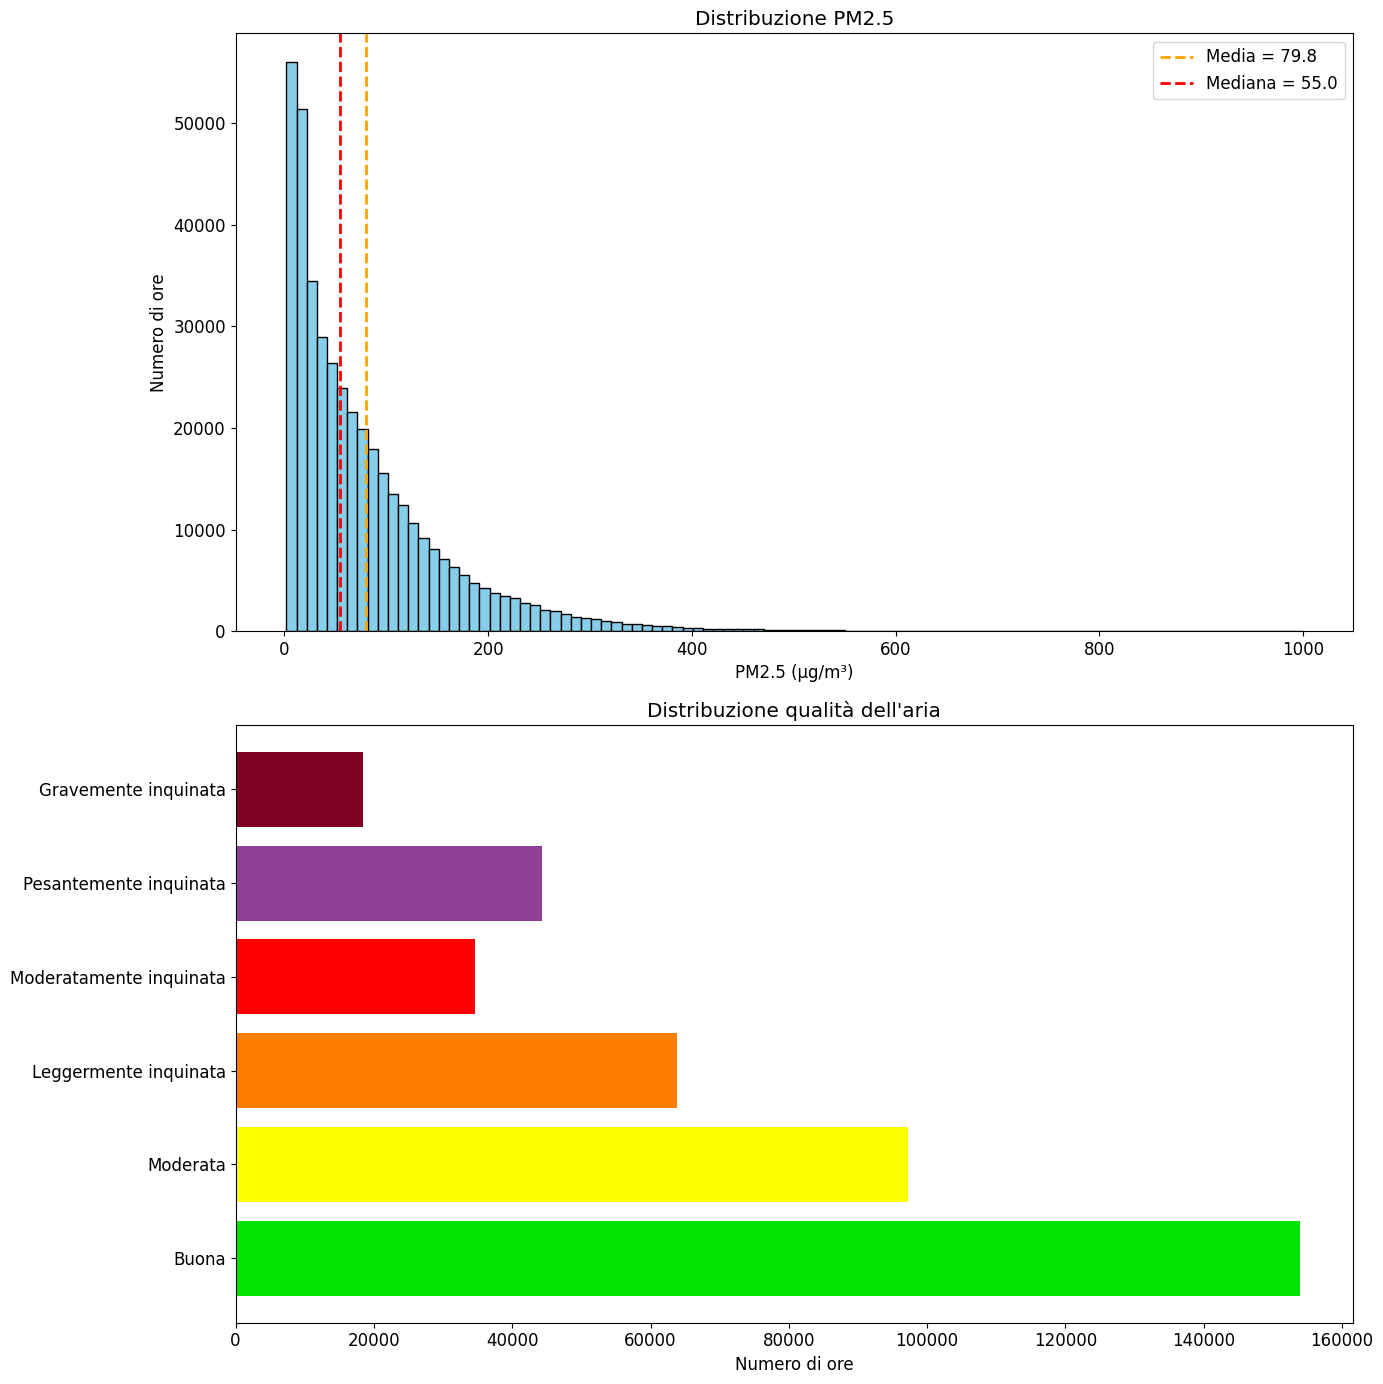

Media: 79.8 µg/m³
Mediana: 55.0 µg/m³
Std: 80.8
Min: 2
Max: 999
Ore con aria buona (≤35): 37.3%
Ore con livelli dannosi (>115): 23.6%


In [5]:
pm25 = df['PM2.5'].dropna()

mean_val = pm25.mean()
median_val = pm25.median()

# Fasce di qualità dell'aria
aqi_labels = ['Buona', 'Moderata', 'Leggermente inquinata', 'Moderatamente inquinata', 'Pesantemente inquinata', 'Gravemente inquinata']
aqi_colors = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']
aqi_bins = [0, 35, 75, 115, 150, 250, np.inf]

aqi_cat = pd.cut(pm25, bins=aqi_bins, labels=aqi_labels, include_lowest=True)
aqi_counts = aqi_cat.value_counts().reindex(aqi_labels)

# Figura
fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Istogramma
axes[0].hist(pm25, bins=100, color='skyblue', edgecolor='black')
axes[0].axvline(mean_val, color='orange', linestyle='--', linewidth=2, label=f'Media = {mean_val:.1f}')
axes[0].axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Mediana = {median_val:.1f}')
axes[0].set_title('Distribuzione PM2.5')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Numero di ore')
axes[0].legend()

# Categorie AQI
axes[1].barh(aqi_counts.index, aqi_counts.values, color=aqi_colors)
axes[1].set_title("Distribuzione qualità dell'aria")
axes[1].set_xlabel('Numero di ore')

# Statistiche
pct_buona = (pm25 <= 35).sum() / len(pm25) * 100
pct_insalubre = (pm25 > 115).sum() / len(pm25) * 100

plt.tight_layout()
plt.show()

print(f"Media: {mean_val:.1f} µg/m³\nMediana: {median_val:.1f} µg/m³")
print(f"Std: {pm25.std():.1f}")
print(f"Min: {pm25.min():.0f}\nMax: {pm25.max():.0f}")
print(f"Ore con aria buona (≤35): {pct_buona:.1f}%")
print(f"Ore con livelli dannosi (>115): {pct_insalubre:.1f}%")

La distribuzione del PM2.5 è asimmetrica: la maggior parte delle ore ha valori tra 0 e 100 µg/m³, ma ci sono picchi che superano i 500 µg/m³. Solo il 37% delle ore ha aria "buona" (≤35 µg/m³), mentre il 23.6% rientra nelle categorie con livelli dannosi.

### 2.3 Analisi temporale

Creazione di un'unica colonna `datetime` a partire dalle variabili temporali separate, da cui si estrae il giorno della settimana `weekday` (0 = lunedì, 6 = domenica).

In [6]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df['weekday'] = df['datetime'].dt.dayofweek

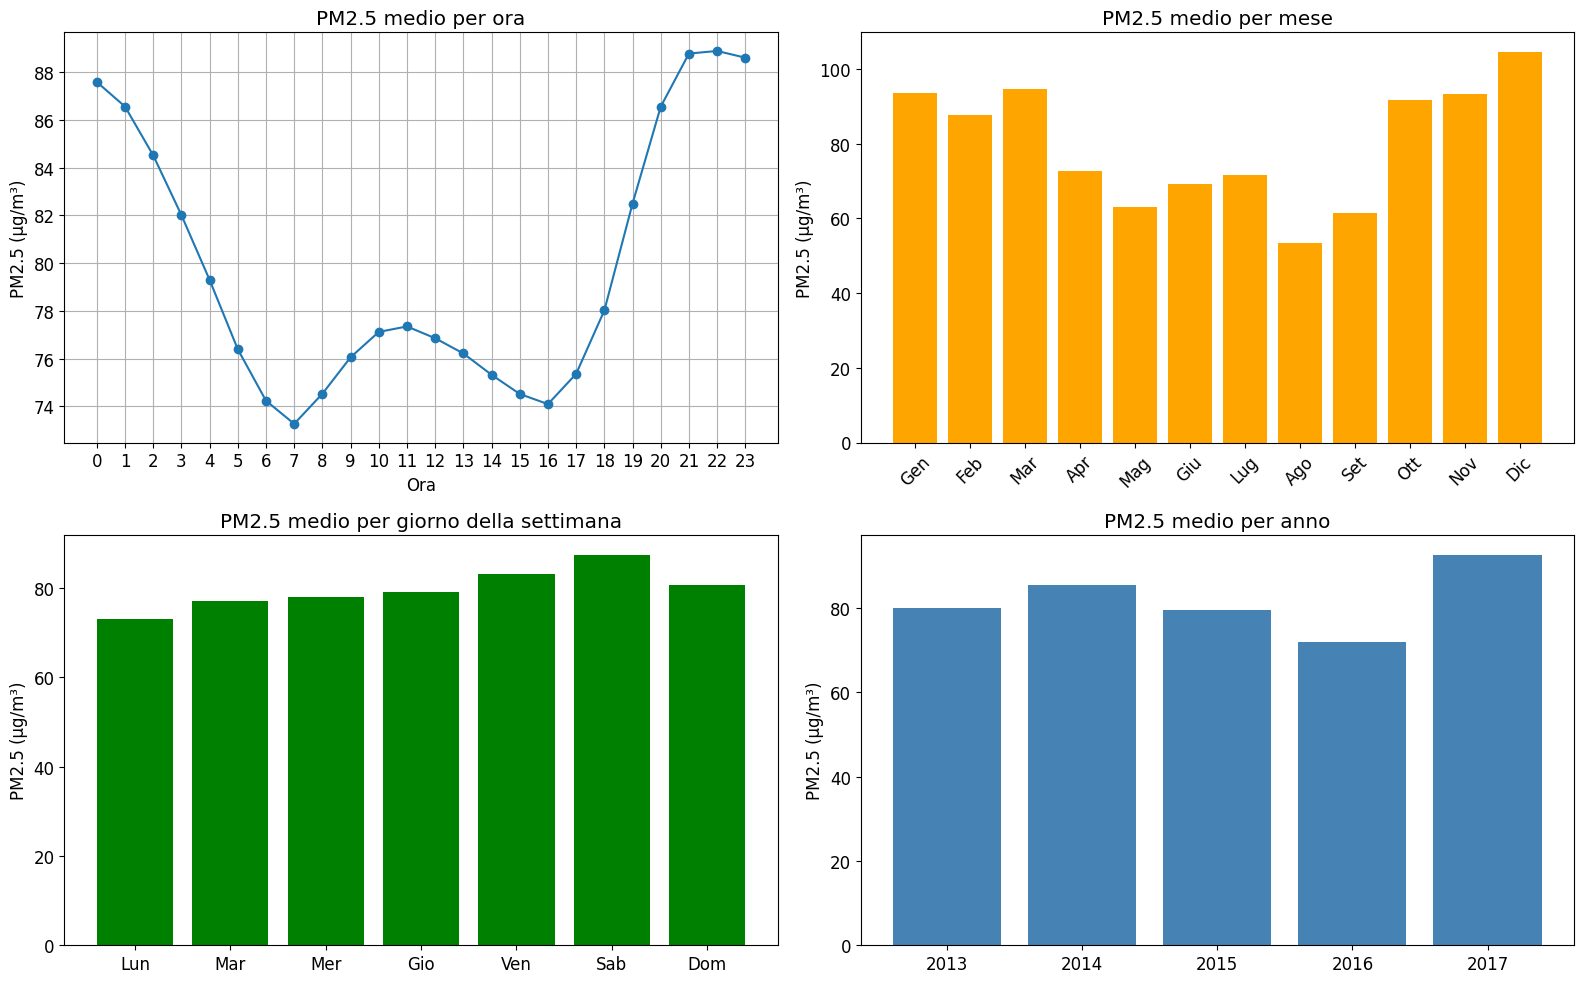

In [7]:
hourly_pm25 = df.groupby('hour')['PM2.5'].mean()
monthly_pm25 = df.groupby('month')['PM2.5'].mean()

mesi = ['Gen', 'Feb', 'Mar', 'Apr', 'Mag', 'Giu', 'Lug', 'Ago', 'Set', 'Ott', 'Nov', 'Dic']

weekday_map = {0:'Lun', 1:'Mar', 2:'Mer', 3:'Gio', 4:'Ven', 5:'Sab', 6:'Dom'}
weekday_pm25 = df.groupby('weekday')['PM2.5'].mean().rename(index=weekday_map)

yearly_pm25 = df.groupby('year')['PM2.5'].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Orario
axes[0,0].plot(hourly_pm25.index, hourly_pm25.values, marker='o')
axes[0,0].set_title('PM2.5 medio per ora')
axes[0,0].set_xlabel('Ora')
axes[0,0].set_ylabel('PM2.5 (µg/m³)')
axes[0,0].set_xticks(range(24))
axes[0,0].grid(True)

# Mensile
axes[0,1].bar(mesi, monthly_pm25.values, color='orange')
axes[0,1].set_title('PM2.5 medio per mese')
axes[0,1].set_ylabel('PM2.5 (µg/m³)')
axes[0,1].tick_params(axis='x', rotation=45)

# Settimanale
axes[1,0].bar(weekday_pm25.index, weekday_pm25.values, color='green')
axes[1,0].set_title('PM2.5 medio per giorno della settimana')
axes[1,0].set_ylabel('PM2.5 (µg/m³)')

# Annuale
axes[1,1].bar(yearly_pm25.index.astype(str), yearly_pm25.values, color='steelblue')
axes[1,1].set_title('PM2.5 medio per anno')
axes[1,1].set_ylabel('PM2.5 (µg/m³)')

plt.tight_layout()
plt.show()

**Orario**: i livelli massimi si registrano durante la notte (18:00–04:00), con un minimo la mattina (6:00–08:00) e nel primo pomeriggio (14:00–17:00).

**Stagionale**: i mesi invernali mostrano valori molto più alti dell'estate.

**Settimanale**: le differenze tra giorni feriali e weekend sono minime. Questo indica che il traffico veicolare non è la causa principale del PM2.5.

**Annuale**: si osserva un lieve miglioramento nel tempo, coerente con le politiche anti-inquinamento adottate.

### 2.4 PM2.5 medio per ora e mese

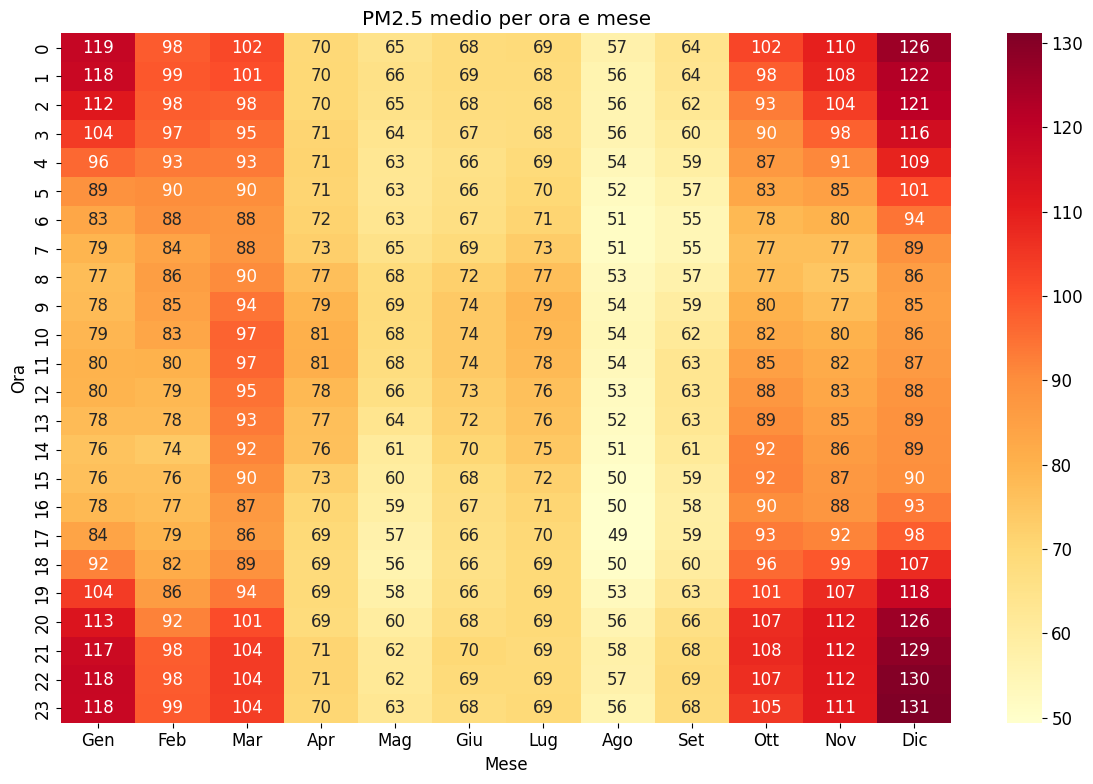

In [8]:
pivot = df.pivot_table(
    values='PM2.5',
    index='hour',
    columns='month',
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f', xticklabels=mesi, yticklabels=range(24))
plt.title('PM2.5 medio per ora e mese')
plt.xlabel('Mese')
plt.ylabel('Ora')
plt.tight_layout()
plt.show()

I mesi invernali (novembre–febbraio) mostrano i valori più elevati in tutte le fasce orarie, a causa del riscaldamento domestico e delle inversioni termiche più frequenti, mentre i mesi estivi (giugno–agosto) presentano i valori più bassi.

Sul piano giornaliero si osserva un picco serale/notturno (tra le 18:00 e le 04:00) e un minimo nel primo pomeriggio (13:00–16:00). La combinazione peggiore è quindi nelle notti invernali, dove i due fattori si sommano.

### 2.5 Distribuzione variabili meteorologiche

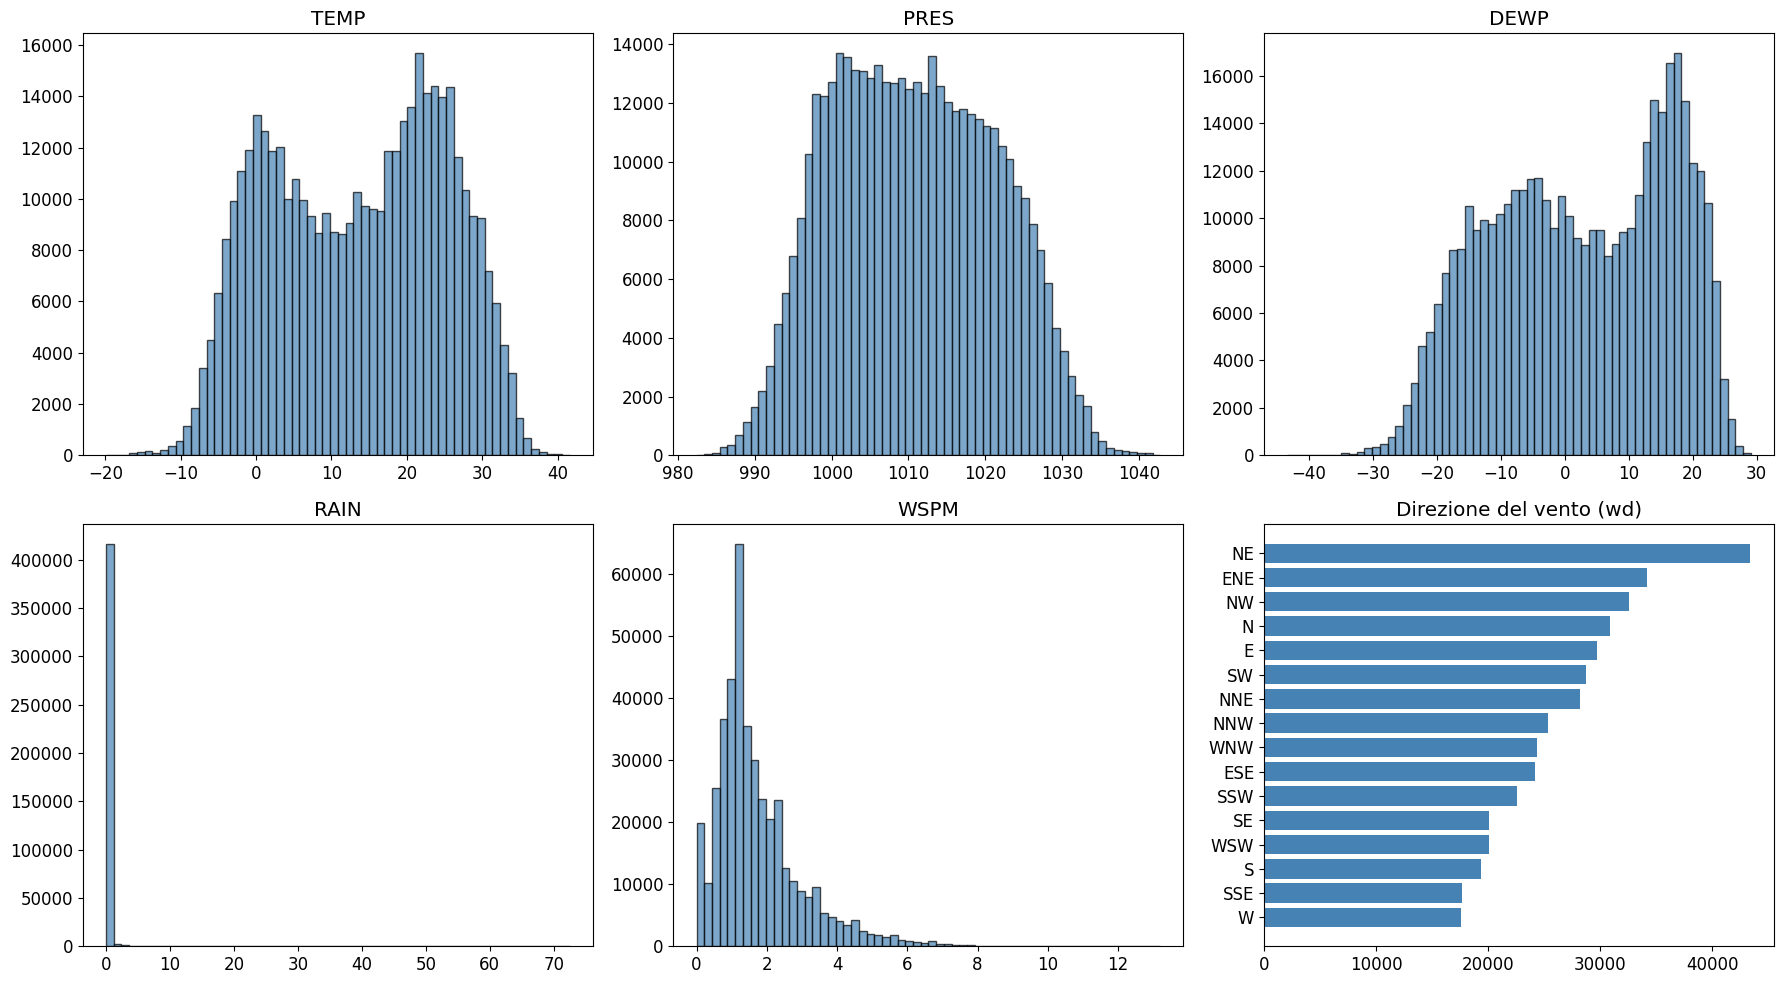

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

meteo_vars = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

for ax, var in zip(axes.flat[:5], meteo_vars):
    data = df[var].dropna()
    ax.hist(data, bins=60, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(var)

wd_counts = df['wd'].value_counts().sort_values(ascending=True)
axes[1,2].barh(wd_counts.index, wd_counts.values, color='steelblue')
axes[1,2].set_title('Direzione del vento (wd)')

plt.tight_layout()
plt.show()

`TEMP` ha un range di circa 60°C (da -20 a +40). `PRES` mostra una distribuzione bimodale legata alla variazione stagionale. `RAIN` è quasi esclusivamente a 0: la stragrande maggioranza delle ore ha precipitazione zero. `WSPM` è concentrato a sinistra, con prevalenza di vento debole. La direzione del vento dominante è NE.

### 2.6 Distribuzione degli inquinanti

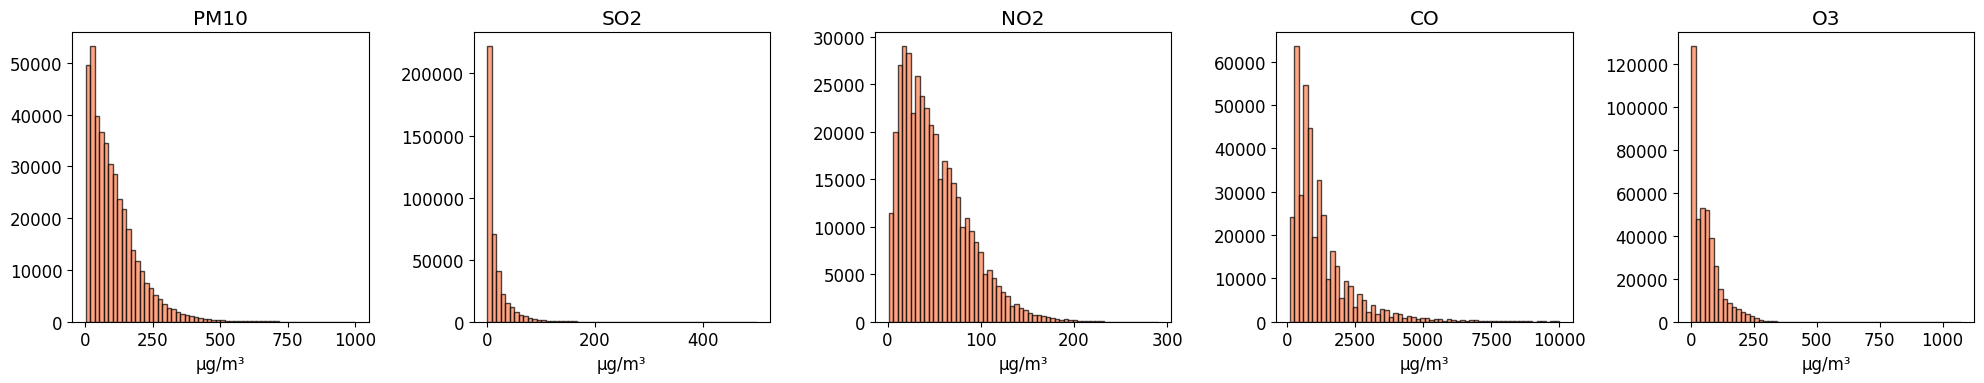

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

poll_vars = ['PM10', 'SO2', 'NO2', 'CO', 'O3']

for ax, var in zip(axes, poll_vars):
    data = df[var].dropna()
    ax.hist(data, bins=60, color='coral', edgecolor='black', alpha=0.7)
    ax.set_title(var)
    ax.set_xlabel('µg/m³')

plt.tight_layout()
plt.show()

Tutti gli inquinanti mostrano una distribuzione concentrata a sinistra, simile a quella del PM2.5, con la maggior parte delle rilevazioni concentrate su valori bassi e una lunga coda verso valori estremi.

### 2.7 Analisi per stazione

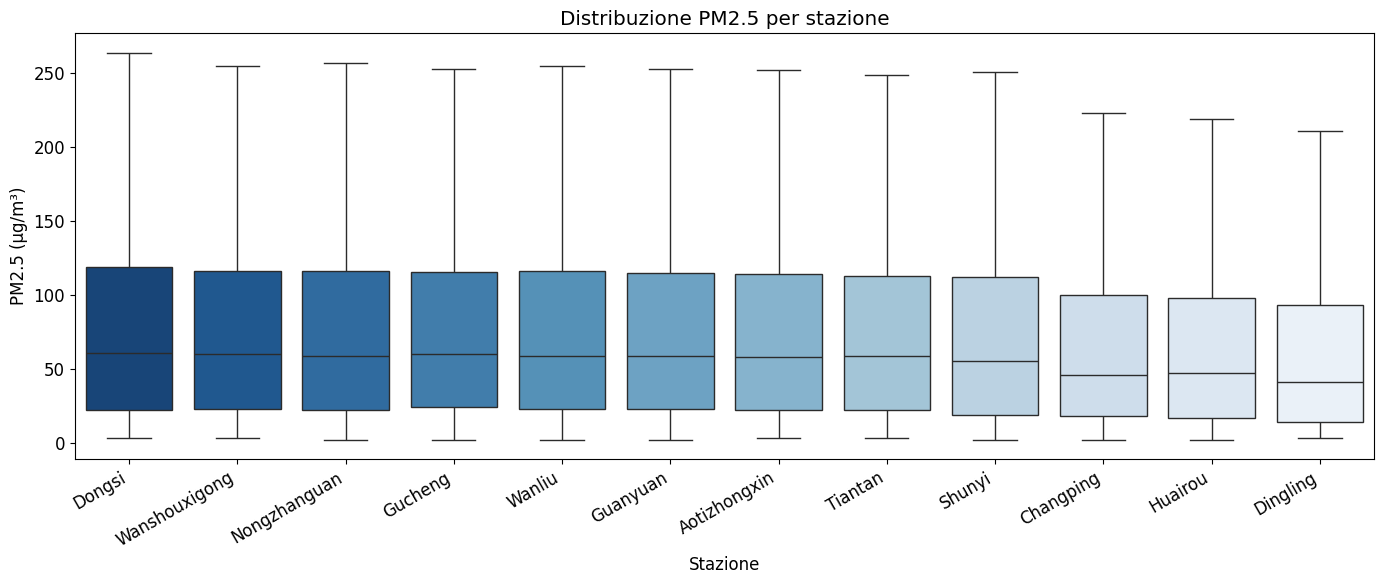

,mean,median,std,count
station,,,,
Dongsi,86.2,61.0,86.6,34314
Wanshouxigong,85.0,60.0,86.0,34368
Nongzhanguan,84.8,59.0,86.2,34436
Gucheng,83.9,60.0,82.8,34418
Wanliu,83.4,59.0,81.9,34682
Guanyuan,82.9,59.0,80.9,34448
Aotizhongxin,82.8,58.0,82.1,34139
Tiantan,82.2,59.0,80.9,34387
Shunyi,79.5,55.0,81.2,34151


In [11]:
station_order = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False).index.tolist()

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='station', y='PM2.5', order=station_order, palette='Blues_r', showfliers=False)
plt.title('Distribuzione PM2.5 per stazione')
plt.ylabel('PM2.5 (µg/m³)')
plt.xlabel('Stazione')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

df.groupby('station')['PM2.5'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False).round(1)

Le stazioni hanno valori medi molto simili tra loro: l'inquinamento da PM2.5 è distribuito in modo relativamente uniforme su scala urbana a Pechino. Questo indica che probabilmente la stazione di rilevamento non sarà un predittore importante.

### 2.8 Correlazione tra le feature

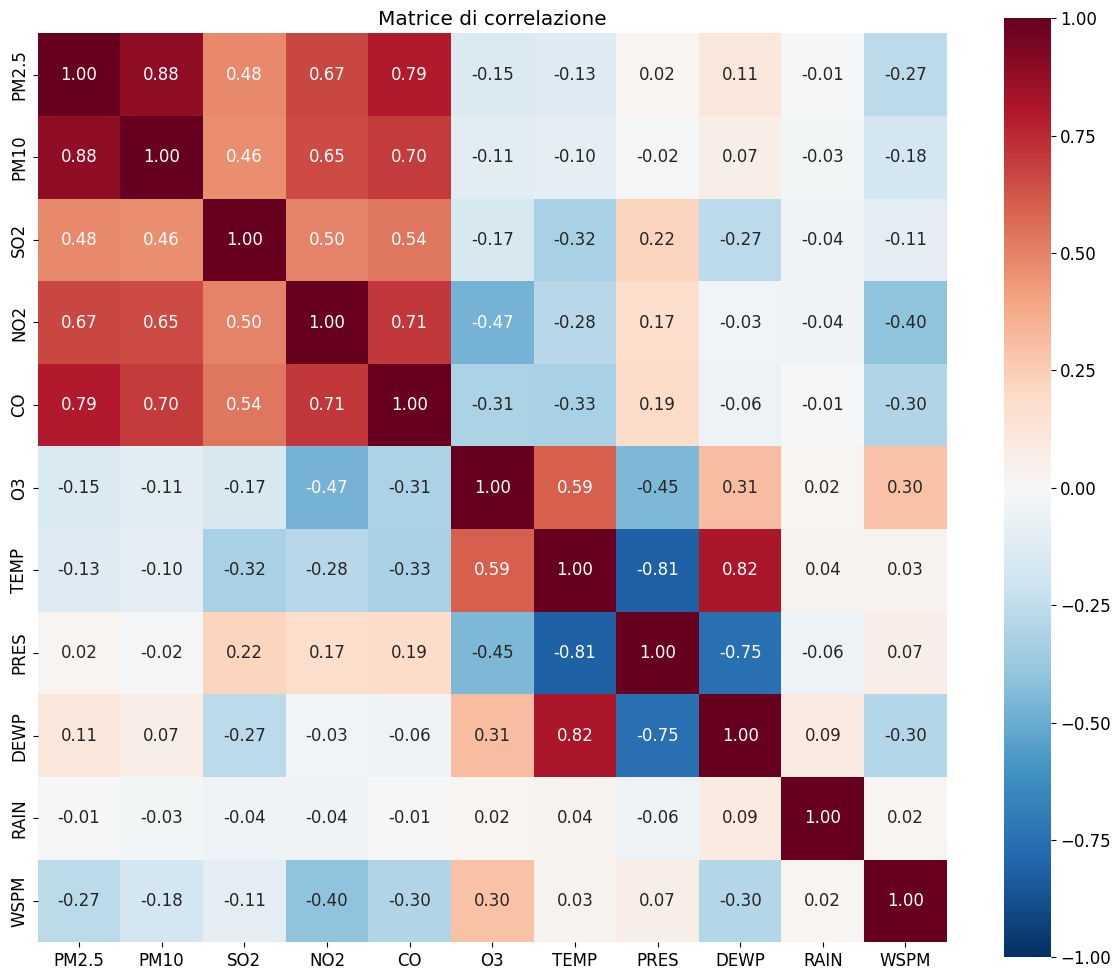

In [12]:
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', square=True, center=0, vmin=-1, vmax=1)
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

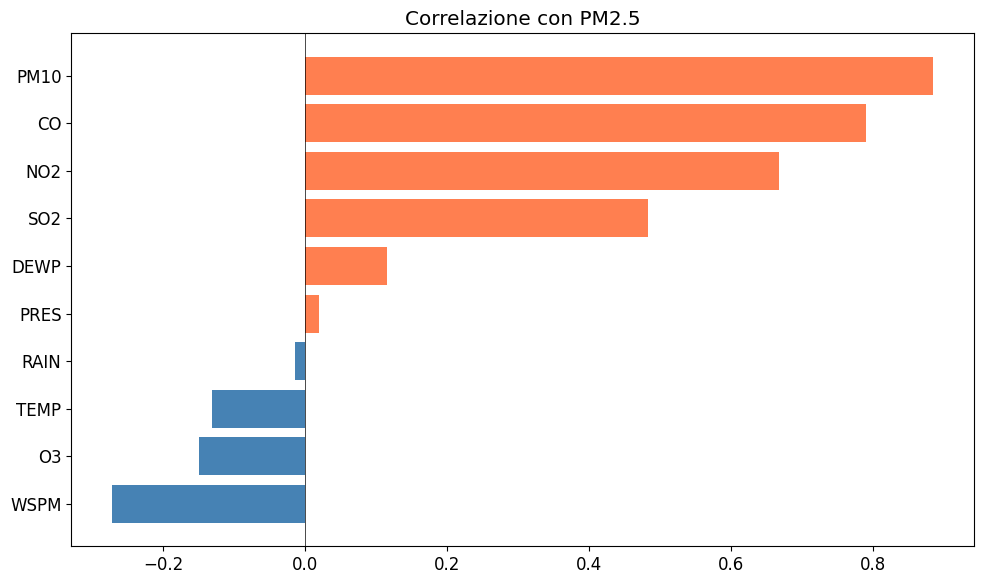

In [13]:
corr_pm25 = corr['PM2.5'].drop('PM2.5').sort_values()

colors = ['steelblue' if v < 0 else 'coral' for v in corr_pm25.values]

plt.figure(figsize=(10, 6))
plt.barh(corr_pm25.index, corr_pm25.values, color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Correlazione con PM2.5')
plt.tight_layout()
plt.show()

Le correlazioni più forti con il PM2.5 sono:

- **CO e PM10** (> 0.7): stesse fonti di emissione, co-emessi con il PM2.5.
- **NO2 e SO2**: correlazione positiva.
- **O3**: correlazione negativa.
- **WSPM**: negativa, il vento disperde il particolato.
- **TEMP**: negativa, in inverno convergono riscaldamento a carbone e inversioni termiche.

### 2.9 Distribuzione di PM2.5 rispetto alle variabili predittive

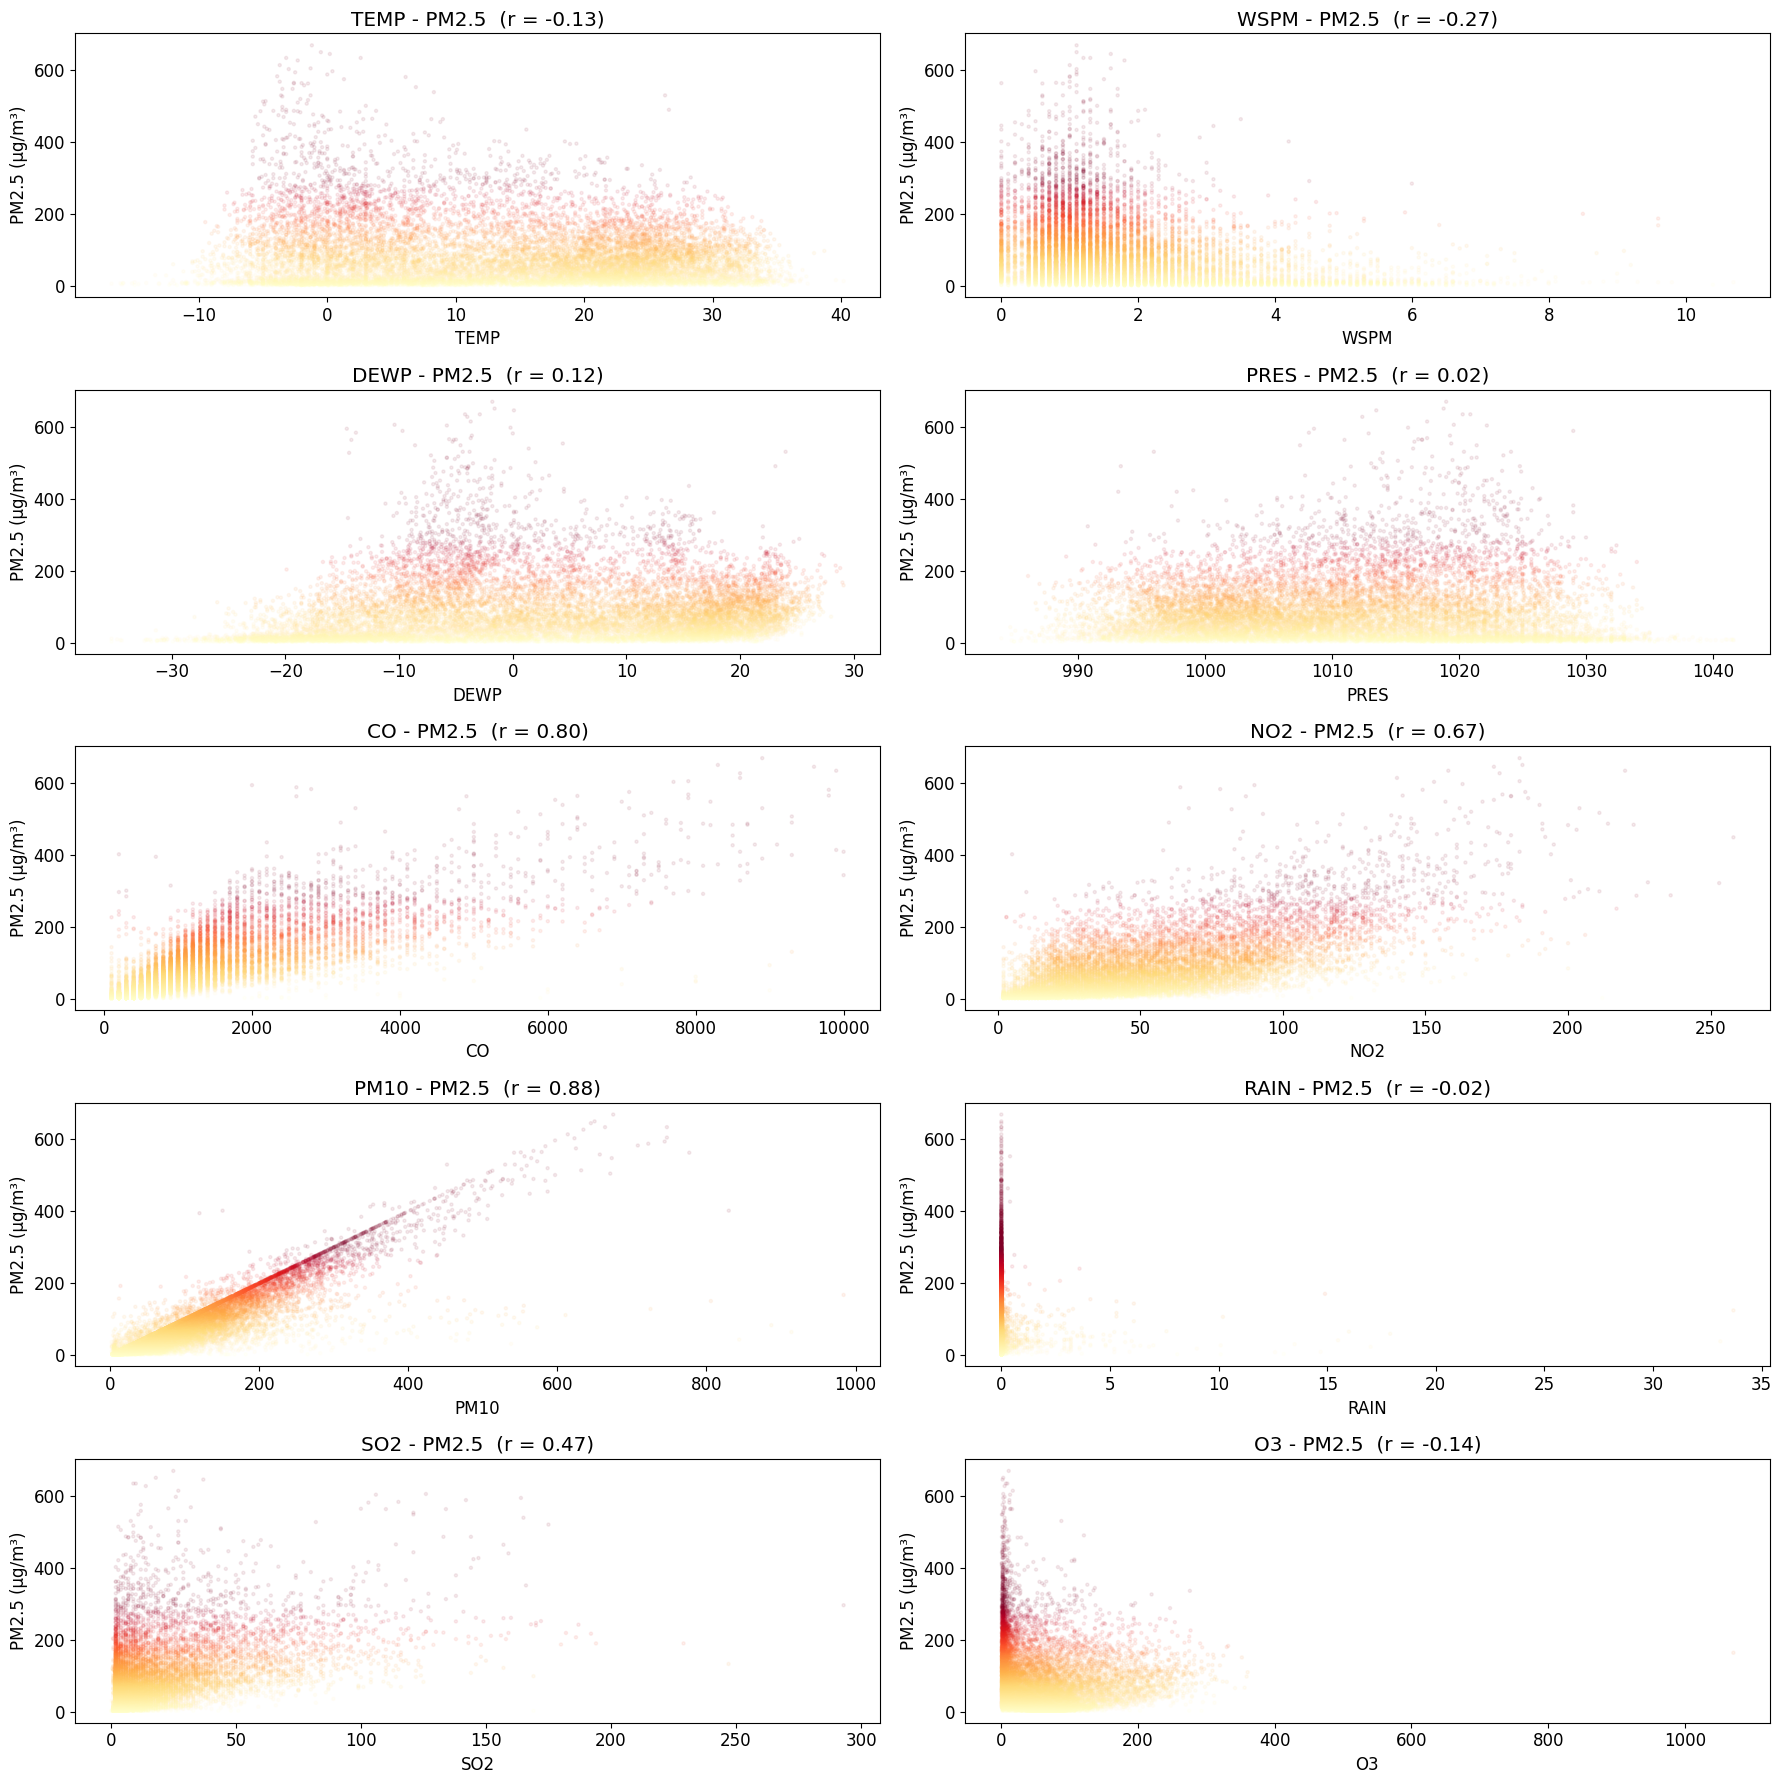

In [14]:
sample = df.dropna(subset=['PM2.5']).sample(n=15000, random_state=42)

scatter_vars = ['TEMP', 'WSPM', 'DEWP', 'PRES', 'CO', 'NO2', "PM10", "RAIN", "SO2", "O3"]

fig, axes = plt.subplots(5, 2, figsize=(18, 18))

for ax, var in zip(axes.flat, scatter_vars):
    r = sample['PM2.5'].corr(sample[var])
    sc = ax.scatter(sample[var], sample['PM2.5'], c=sample['PM2.5'], cmap='YlOrRd', alpha=0.08, s=5, vmax=300)
    ax.set_xlabel(var)
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'{var} - PM2.5  (r = {r:.2f})')

plt.tight_layout()
plt.show()

Tra gli inquinanti, PM10 risulta il predittore più forte con una correlazione di 0.88: la relazione è quasi lineare, a conferma che i due particolati condividono le stesse sorgenti di emissione. L'ozono invece mostra una correlazione negativa (-0.16).

Per le feature meteorologiche, la velocità del vento è la variabile più rilevante (-0.27): venti forti favoriscono la dispersione del particolato. La temperatura (-0.14) riflette l'effetto dei sistemi di riscaldamento, mentre pressione (0.04) e pioggia (-0.02) mostrano correlazioni trascurabili.

## 3. Preparazione dei dati

### 3.1 Gestione valori mancanti

I NaN sono causati da guasti dei sensori e rappresentano meno del 5% dei dati. Data la bassa percentuale, vengono rimosse le righe con valori mancanti.

In [15]:
df_model = df.copy()
before = len(df_model)
df_model = df_model.dropna()
after = len(df_model)
print(f"Righe rimosse: {before - after}")
print(f"Righe rimaste: {after}")

Righe rimosse: 38600
Righe rimaste: 382168


### 3.2 Codifica ciclica

Diverse variabili nel dataset sono cicliche: l'ora del giorno, il mese e il giorno della settimana. La codifica numerica grezza non rispetta questa periodicità. La trasformazione in sin e cos risolve il problema, mappando ogni valore su una circonferenza dove gli estremi si toccano.

La direzione del vento viene trattata allo stesso modo: essendo una variabile categorica "circolare", la codifica sin/cos preserva la continuità tra direzioni adiacenti.

Si estrae inoltre un flag binario `is_weekend` per distinguere i giorni feriali dai festivi.

In [16]:
# Giorno della settimana e weekend
df_model['dayofweek'] = df_model['datetime'].dt.dayofweek
df_model['is_weekend'] = (df_model['dayofweek'] >= 5).astype(int)

# Codifica ciclica variabili temporali
df_model['hour_sin'] = np.sin(2 * np.pi * df_model['hour'] / 24)
df_model['hour_cos'] = np.cos(2 * np.pi * df_model['hour'] / 24)
df_model['month_sin'] = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
df_model['dow_sin'] = np.sin(2 * np.pi * df_model['dayofweek'] / 7)
df_model['dow_cos'] = np.cos(2 * np.pi * df_model['dayofweek'] / 7)

# Codifica ciclica direzione del vento
wd_to_deg = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}
wd_rad = np.deg2rad(df_model['wd'].map(wd_to_deg))
df_model['wd_sin'] = np.sin(wd_rad)
df_model['wd_cos'] = np.cos(wd_rad)

# Rimozione delle colonne originali
df_model.drop(columns=['hour', 'month', 'dayofweek', 'day', 'weekday', 'wd'], inplace=True)

### 3.3 Rimozione valori anomali

Valori di PM2.5 > 500 µg/m³ corrispondono a eventi eccezionali o a malfunzionamenti dei sensori. Sono rari e possono distorcere i modelli lineari.

In [17]:
before = len(df_model)
df_model = df_model[df_model['PM2.5'] <= 500].reset_index(drop=True)
after = len(df_model)
print(f"Righe rimosse: {before - after:,}")
print(f"Righe rimaste: {after}")

Righe rimosse: 750
Righe rimaste: 381418


### 3.4 Esclusione della feature PM10

PM10 ha una correlazione di ~0.9 con il PM2.5 perché il PM2.5 è fisicamente un sottoinsieme del PM10. Includere PM10 come feature renderebbe la predizione banale: il modello si appoggerebbe quasi interamente su di esso ignorando gli altri predittori.

In [18]:
pm10_saved = df_model['PM10'].copy()
df_model.drop(columns=['PM10'], inplace=True)

### 3.5 Split temporale

Viene effettuato uno split temporale: il training set comprende i dati fino al 2016-09-01, il test set gli ultimi ~6 mesi. In un problema con struttura temporale, uno split casuale causerebbe data leakage perché il modello vedrebbe dati futuri durante il training.

In [19]:
split_date = pd.Timestamp('2016-09-01')
train_mask = df_model['datetime'] < split_date
test_mask = ~train_mask

print(f"Train: {train_mask.sum()} righe")
print(f"Test:  {test_mask.sum()} righe")

Train: 333282 righe
Test:  48136 righe


### 3.6 Target encoding

Per la stazione viene utilizzato il target encoding: ogni stazione viene sostituita con la media storica del PM2.5. La media è calcolata solo sul training set per evitare data leakage.

In [20]:
station_mean = (
    df_model.loc[train_mask]
    .groupby('station')['PM2.5']
    .mean()
)

df_model['station_target_enc'] = df_model['station'].map(station_mean)
df_model.drop(columns=['station'], inplace=True)

### 3.7 Preparazione finale

Il target `PM2.5` viene separato dalle feature predittive. Le colonne `datetime` e `year` vengono rimosse: la prima è una colonna di appoggio non informativa, la seconda è già rappresentata indirettamente dalle feature cicliche del mese.

Il dataset viene infine suddiviso in training e test set rispettando l'ordine temporale, per evitare data leakage.

In [21]:
# Target e feature
y = df_model['PM2.5']

# Colonne da rimuovere
drop_cols = ['PM2.5', 'datetime', 'year']

X = df_model.drop(columns=drop_cols)

# Split finale
X_train = X[train_mask]
X_test  = X[test_mask]
y_train = y[train_mask]
y_test  = y[test_mask]
pm10_train = pm10_saved[train_mask]
pm10_test = pm10_saved[test_mask]

# Info
print(f"Righe Train set: {X_train.shape[0]}")
print(f"Righe Test set: {X_test.shape[0]}")
print(f"Feature: {X.shape[1]}\n")

X_train.info(verbose=False, memory_usage='deep')
X_train.head(1)

Righe Train set: 333282
Righe Test set: 48136
Feature: 19

<class 'pandas.core.frame.DataFrame'>
Index: 333282 entries, 0 to 377343
Columns: 19 entries, SO2 to station_target_enc
dtypes: float64(18), int64(1)
memory usage: 50.9 MB


,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,is_weekend,hour_sin,hour_cos,month_sin,month_cos,dow_sin,dow_cos,wd_sin,wd_cos,station_target_enc
0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,5.7,0,0.0,1.0,1.0,6.123234e-17,-0.433884,-0.900969,-0.382683,0.92388,81.382535


## 4. Modelli di Regressione

### 4.1 Funzione di valutazione

Viene definita una funzione unica di valutazione che calcola le principali metriche di regressione.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = [] # lista dei risultati

tscv = TimeSeriesSplit(n_splits=5)

def evaluate(y_true, preds, name=''):
    mse = mean_squared_error(y_true, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)
    rel_error = mae / np.mean(y_true)

    metrics = {
        'model': name,
        'RMSE': rmse,
        'MAE': mae,
        'Relative Error': rel_error,
        'R2': r2
    }

    print(f"{name}:")
    print(f"\tRMSE:\t\t\t{rmse:.3f}")
    print(f"\tMAE:\t\t\t{mae:.3f}")
    print(f"\tRelative error:\t\t{rel_error:.3f}")
    print(f"\tR-2 coefficient:\t{r2:.3f}\n")
    
    return metrics

def evaluate_model(X, y, model, name=''):
    preds = model.predict(X)
    return evaluate(y, preds, name)

### 4.2 DummyRegressor

Il primo modello di riferimento è un DummyRegressor, che predice sempre la media del PM2.5 calcolata sul training set, ignorando completamente tutte le feature disponibili.

Questo modello non utilizza alcuna informazione predittiva ed è utile come baseline: qualsiasi modello più avanzato deve necessariamente ottenere prestazioni migliori. In questo caso, il valore di R² è circa 0, poiché non spiega alcuna variabilità del target.

In [23]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='mean')

%time dummy.fit(X_train, y_train)

CPU times: user 574 μs, sys: 162 μs, total: 736 μs
Wall time: 605 μs


DummyRegressor()

In [24]:
train_eval = evaluate_model(X_train, y_train, dummy, 'DummyRegressor - Train')
test_eval = evaluate_model(X_test, y_test, dummy, 'DummyRegressor - Test')

results.append(test_eval)

DummyRegressor - Train:
	RMSE:			74.486
	MAE:			55.918
	Relative error:		0.728
	R-2 coefficient:	0.000

DummyRegressor - Test:
	RMSE:			93.921
	MAE:			69.927
	Relative error:		0.777
	R-2 coefficient:	-0.020



Il modello produce un errore elevato e un R² prossimo a zero. Questo conferma che la semplice media storica del PM2.5 non è sufficiente a catturare il fenomeno e rappresenta quindi una soglia minima di prestazione per qualsiasi modello successivo.

### 4.3 Regressione Lineare

La regressione lineare rappresenta il primo modello “reale”.

Poiché le variabili hanno scale molto diverse, si utilizza una Pipeline con StandardScaler per standardizzare i dati prima della regressione. Il modello non include alcuna regolarizzazione, così da valutare la capacità della semplice relazione lineare tra feature e target.

In [25]:
from sklearn.linear_model import LinearRegression

linear = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

%time linear.fit(X_train, y_train)

CPU times: user 270 ms, sys: 89 ms, total: 359 ms
Wall time: 228 ms


Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [26]:
train_eval = evaluate_model(X_train, y_train, linear, 'Linear Regression - Train')
test_eval = evaluate_model(X_test, y_test, linear, 'Linear Regression - Test')

results.append(test_eval)

Linear Regression - Train:
	RMSE:			40.001
	MAE:			27.712
	Relative error:		0.361
	R-2 coefficient:	0.712

Linear Regression - Test:
	RMSE:			42.725
	MAE:			30.160
	Relative error:		0.335
	R-2 coefficient:	0.789



### 4.4 Lasso Regression

Il Lasso aggiunge una penalità L1 ai coefficienti, che può azzerarli completamente effettuando una selezione automatica delle variabili. L'iperparametro alpha controlla l'intensità della regolarizzazione e viene selezionato con GridSearchCV.

In [27]:
from sklearn.linear_model import Lasso

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

grid = {'lasso__alpha': [0.05, 0.1, 0.5, 1]}
gs_lasso = GridSearchCV(lasso, grid, cv=5)
%time gs_lasso.fit(X_train, y_train)

CPU times: user 26.1 s, sys: 24.7 s, total: 50.8 s
Wall time: 25.6 s


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lasso', Lasso())]),
             param_grid={'lasso__alpha': [0.05, 0.1, 0.5, 1]})

In [28]:
train_eval = evaluate_model(X_train, y_train, gs_lasso, "Lasso - Train")
test_eval = evaluate_model(X_test, y_test, gs_lasso, "Lasso - Test")

results.append(test_eval)

Lasso - Train:
	RMSE:			40.003
	MAE:			27.673
	Relative error:		0.360
	R-2 coefficient:	0.712

Lasso - Test:
	RMSE:			42.677
	MAE:			30.076
	Relative error:		0.334
	R-2 coefficient:	0.789



#### Analisi dei coefficienti di Lasso

In [29]:
print(f"Alpha ottimale: {gs_lasso.best_params_['lasso__alpha']}")

coef_lasso = pd.Series(
    gs_lasso.best_estimator_.named_steps['lasso'].coef_,
    index=X_train.columns
)

non_zero = coef_lasso[coef_lasso != 0].sort_values()
zero = coef_lasso[coef_lasso == 0]

print("\nFeature escluse:")
print(zero)

Alpha ottimale: 0.05

Feature escluse:
TEMP        0.0
hour_cos   -0.0
dtype: float64


Il GridSearchCV ha selezionato alpha = 0.05.
Lasso ha azzerato i coefficienti di `TEMP` e `hour_cos`, escludendole dal modello.

### 4.5 Ridge Regression

La Ridge aggiunge una penalità L2 ai coefficienti: li riduce uniformemente senza azzerarli, rendendola più stabile in presenza di multicollinearità. Anche in questo caso, alpha viene selezionato con GridSearchCV.

In [30]:
from sklearn.linear_model import Ridge

ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

grid = {'ridge__alpha': [0.05, 0.1, 1, 10, 50, 100]}
gs_ridge = GridSearchCV(ridge, grid, cv=tscv)

%time gs_ridge.fit(X_train, y_train)

CPU times: user 3.7 s, sys: 6.15 s, total: 9.85 s
Wall time: 4.98 s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             param_grid={'ridge__alpha': [0.05, 0.1, 1, 10, 50, 100]})

In [31]:
print(f"Alpha ottimale: {gs_ridge.best_params_['ridge__alpha']}\n")

train_eval = evaluate_model(X_train, y_train, gs_ridge, "Ridge - Train")
test_eval = evaluate_model(X_test, y_test, gs_ridge, "Ridge - Test")

results.append(test_eval)

Alpha ottimale: 0.05

Ridge - Train:
	RMSE:			40.001
	MAE:			27.712
	Relative error:		0.361
	R-2 coefficient:	0.712

Ridge - Test:
	RMSE:			42.725
	MAE:			30.160
	Relative error:		0.335
	R-2 coefficient:	0.789



### 4.6 ElasticNet

L'ElasticNet combina le penalità L1 e L2, controllate dai parametri alpha e l1_ratio. Questo permette sia la selezione delle feature (L1) sia la stabilità con variabili correlate (L2).

In [32]:
from sklearn.linear_model import ElasticNet

elasticnet = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', ElasticNet())
])

grid = {
    'regr__alpha': [0.05, 0.1, 0.5, 1],
    'regr__l1_ratio': [0.05, 0.1, 0.25, 0.5]
}

gs_elasticnet = GridSearchCV(elasticnet, grid, cv=tscv, scoring='r2')

%time gs_elasticnet.fit(X_train, y_train)

CPU times: user 46.2 s, sys: 59.4 s, total: 1min 45s
Wall time: 53 s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('regr', ElasticNet())]),
             param_grid={'regr__alpha': [0.05, 0.1, 0.5, 1],
                         'regr__l1_ratio': [0.05, 0.1, 0.25, 0.5]},
             scoring='r2')

In [33]:
print(f"Alpha ottimale:    {gs_elasticnet.best_params_['regr__alpha']}")
print(f"L1 ratio ottimale: {gs_elasticnet.best_params_['regr__l1_ratio']}\n")

train_eval = evaluate_model(X_train, y_train, gs_elasticnet, "Elastic Net - Train")
test_eval = evaluate_model(X_test, y_test, gs_elasticnet, "Elastic Net - Test")

results.append(test_eval)

Alpha ottimale:    0.05
L1 ratio ottimale: 0.5

Elastic Net - Train:
	RMSE:			40.195
	MAE:			27.443
	Relative error:		0.357
	R-2 coefficient:	0.709

Elastic Net - Test:
	RMSE:			42.296
	MAE:			29.248
	Relative error:		0.325
	R-2 coefficient:	0.793



### 4.7 Regressione Polinomiale

La regressione polinomiale espande le feature con termini quadratici e prodotti tra coppie di variabili, permettendo di catturare relazioni non lineari. Si combina con Ridge per regolarizzare i coefficienti aggiuntivi e ridurre 
l'overfitting.

In [34]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

poly_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge())
])

grid = {'ridge__alpha': [1, 10, 50, 100, 200, 500, 1000]}
gs_poly = GridSearchCV(poly_ridge, grid, cv=tscv, scoring='r2', n_jobs=-1)

%time gs_poly.fit(X_train, y_train)

CPU times: user 1.62 s, sys: 302 ms, total: 1.92 s
Wall time: 17 s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'ridge__alpha': [1, 10, 50, 100, 200, 500, 1000]},
             scoring='r2')

In [35]:
print(f"Alpha ottimale: {gs_poly.best_params_['ridge__alpha']}")

train_eval = evaluate_model(X_train, y_train, gs_poly, "Polinomiale - Train")
test_eval = evaluate_model(X_test, y_test, gs_poly, "Polinomiale - Test")

results.append(test_eval)

Alpha ottimale: 1000
Polinomiale - Train:
	RMSE:			34.057
	MAE:			22.663
	Relative error:		0.295
	R-2 coefficient:	0.791

Polinomiale - Test:
	RMSE:			41.728
	MAE:			26.163
	Relative error:		0.291
	R-2 coefficient:	0.799



### 4.8 Random Forest

Il Random Forest combina più alberi decisionali, ognuno addestrato su un sottoinsieme casuale dei dati e delle feature. Cattura naturalmente non linearità e interazioni senza bisogno di feature engineering esplicito.

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', RandomForestRegressor(random_state=SEED, n_jobs=5))
])

param_dist = {
    'regr__n_estimators':      [300, 500, 700],
    'regr__max_depth':         [8, 10, 12, 15],
    'regr__min_samples_split': [10, 20, 30],
    'regr__min_samples_leaf':  [5, 10, 15],
    'regr__max_features':      ['sqrt'],
    'regr__max_samples':       [0.3, 0.4, 0.5, 0.6],
}

rs_rf = RandomizedSearchCV(
    rf, param_dist,
    n_iter=50, cv=tscv,
    scoring='r2',
    random_state=SEED,
    n_jobs=2
)

rs_rf = RandomizedSearchCV(rf, param_dist, n_iter=10, cv=tscv, scoring='r2', random_state=SEED, n_jobs=-1)

%time rs_rf.fit(X_train, y_train)

CPU times: user 1min 22s, sys: 674 ms, total: 1min 22s
Wall time: 21min 7s


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('regr',
                                              RandomForestRegressor(n_jobs=5,
                                                                    random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'regr__max_depth': [8, 10, 12, 15],
                                        'regr__max_features': ['sqrt'],
                                        'regr__max_samples': [0.3, 0.4, 0.5,
                                                              0.6],
                                        'regr__min_samples_leaf': [5, 10, 15],
                                        'regr__min_samples_split': [10, 20, 30],
                                        'regr__n_estimators': [300, 500, 700]},
                   random_state=42, scoring='r2')

In [37]:
train_eval = evaluate_model(X_train, y_train, rs_rf, "Random Forest - Train")
test_eval = evaluate_model(X_test, y_test, rs_rf, "Random Forest - Test")

results.append(test_eval)

Random Forest - Train:
	RMSE:			25.946
	MAE:			17.003
	Relative error:		0.221
	R-2 coefficient:	0.879

Random Forest - Test:
	RMSE:			38.816
	MAE:			23.872
	Relative error:		0.265
	R-2 coefficient:	0.826



### 4.9 XGBoost

XGBoost è un algoritmo di gradient boosting che costruisce alberi in sequenza, dove ogni albero corregge gli errori del precedente. È generalmente il modello più performante per dati tabulari. Si usa RandomizedSearchCV dato il maggior numero di iperparametri.

In [38]:
from xgboost import XGBRegressor

xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(
        random_state=SEED,
        n_jobs=-1,
        tree_method='hist',
        min_child_weight=5,
        gamma=0.1
    ))
])

param_dist = {
    'xgb__n_estimators':     [200, 400],
    'xgb__max_depth':        [3, 4],
    'xgb__learning_rate':    [0.05, 0.1],
    'xgb__subsample':        [0.7, 0.8],
    'xgb__colsample_bytree': [0.7, 0.8],
    'xgb__reg_alpha':        [0.5, 1, 5],
    'xgb__reg_lambda':       [5, 10],
}

rs_xgb = RandomizedSearchCV(xgb, param_dist, n_iter=20, cv=tscv, scoring='r2', random_state=SEED, n_jobs=-1)

%time rs_xgb.fit(X_train, y_train)

CPU times: user 7.45 s, sys: 0 ns, total: 7.45 s
Wall time: 2min 12s


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('xgb',
                                              XGBRegressor(base_score=None,
                                                           booster=None,
                                                           callbacks=None,
                                                           colsample_bylevel=None,
                                                           colsample_bynode=None,
                                                           colsample_bytree=None,
                                                           device=None,
                                                           early_stopping_rounds=None,
                                                           enable_categorical=False,
                                                           eval_metri...
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=None,
                                                           n_jobs=-1,
                                                           num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'xgb__colsample_bytree': [0.7, 0.8],
                                        'xgb__learning_rate': [0.05, 0.1],
                                        'xgb__max_depth': [3, 4],
                                        'xgb__n_estimators': [200, 400],
                                        'xgb__reg_alpha': [0.5, 1, 5],
                                        'xgb__reg_lambda': [5, 10],
                                        'xgb__subsample': [0.7, 0.8]},
                   random_state=42, scoring='r2')

In [39]:
train_eval = evaluate_model(X_train, y_train, rs_xgb, "XGBoost - Train")
test_eval = evaluate_model(X_test, y_test, rs_xgb, "XGBoost - Test")

results.append(test_eval)

XGBoost - Train:
	RMSE:			30.034
	MAE:			19.658
	Relative error:		0.256
	R-2 coefficient:	0.837

XGBoost - Test:
	RMSE:			39.661
	MAE:			24.470
	Relative error:		0.272
	R-2 coefficient:	0.818



### 4.10 Tabella comparativa

In [40]:
results_df = pd.DataFrame(results)
results_df = results_df.set_index('model')
results_df = results_df.round(3)
results_df.sort_values('R2', ascending=False)

,RMSE,MAE,Relative Error,R2
model,,,,
Random Forest - Test,38.816,23.872,0.265,0.826
XGBoost - Test,39.661,24.470,0.272,0.818
Polinomiale - Test,41.728,26.163,0.291,0.799
Elastic Net - Test,42.296,29.248,0.325,0.793
Linear Regression - Test,42.725,30.160,0.335,0.789
Lasso - Test,42.677,30.076,0.334,0.789
Ridge - Test,42.725,30.160,0.335,0.789
DummyRegressor - Test,93.921,69.927,0.777,-0.020


Random Forest ottiene le performance migliori (R² = 0.823), seguito a breve distanza da XGBoost (R² = 0.815).

La regressione polinomiale (R² = 0.798) migliora rispetto ai modelli lineari puri, confermando la presenza di relazioni non lineari nel dataset. ElasticNet, Lasso e Ridge ottengono risultati quasi identici (R² ≈ 0.789–0.793), a indicare che la regolarizzazione non porta vantaggi significativi rispetto alla regressione lineare base su questo dataset.

L'errore relativo di Random Forest pari a 0.267 indica che in media il modello sbaglia del 26.7% rispetto al valore reale, un risultato accettabile considerando la forte variabilità e la presenza di picchi estremi nel dataset.

## 5. Analisi e interpretazione dei modelli migliori

In questa sezione vengono analizzati nel dettaglio i modelli migliori per ciascuna categoria: ElasticNet per i modelli lineari, la regressione polinomiale, Random Forest e XGBoost. Per i modelli lineari si esaminano i coefficienti delle feature, mentre per i modelli ad albero si analizza la feature importance e la struttura dei primi nodi per individuare le variabili più rilevanti nella predizione del PM2.5.

### 5.1 Coefficienti della regressione lineare (ElasticNet)

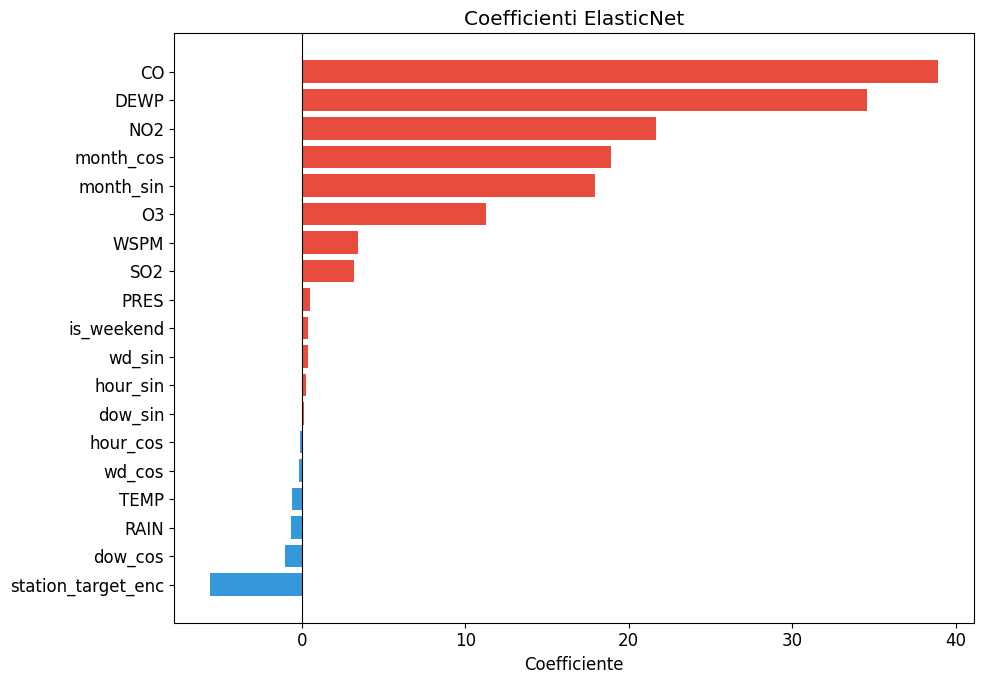


feature più positive:
month_sin    17.910125
month_cos    18.931595
NO2          21.698637
DEWP         34.559871
CO           38.905660
dtype: float64

feature più negative:
station_target_enc   -5.601508
dow_cos              -1.004168
RAIN                 -0.652289
TEMP                 -0.609720
wd_cos               -0.156773
dtype: float64


In [41]:
coef = pd.Series(
    gs_elasticnet.best_estimator_['regr'].coef_,
    index=X_train.columns
).sort_values()

colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef]

plt.figure(figsize=(10, 7))
plt.barh(coef.index, coef.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coefficienti ElasticNet')
plt.xlabel('Coefficiente')
plt.tight_layout()
plt.show()

print(f"\nfeature più positive:\n{coef.tail(5)}")
print(f"\nfeature più negative:\n{coef.head(5)}")

Tra i coefficienti positivi, CO e DEWP sono i più influenti, seguiti da NO2 e dalle componenti cicliche del mese (month_sin, month_cos), che confermano la forte stagionalità del PM2.5 già osservata nell'analisi esplorativa. Sorprende il coefficiente positivo di O3 e WSPM, che negli scatter plot mostravano una correlazione negativa: in un modello lineare multivariato le correlazioni tra feature possono alterare il segno dei coefficienti (multicollinearità).

Sul fronte negativo, station_target_enc ha il coefficiente più grande in valore assoluto (-5.6), indicando che stazioni con una media storica di PM2.5 più alta tendono paradossalmente a predire valori più bassi nel modello lineare, probabilmente per effetti di compensazione con le altre feature. TEMP e RAIN mostrano coefficienti negativi contenuti, coerenti con il loro ruolo di fattori di dispersione del particolato.

### 5.2 Coefficienti della regressione polinomiale

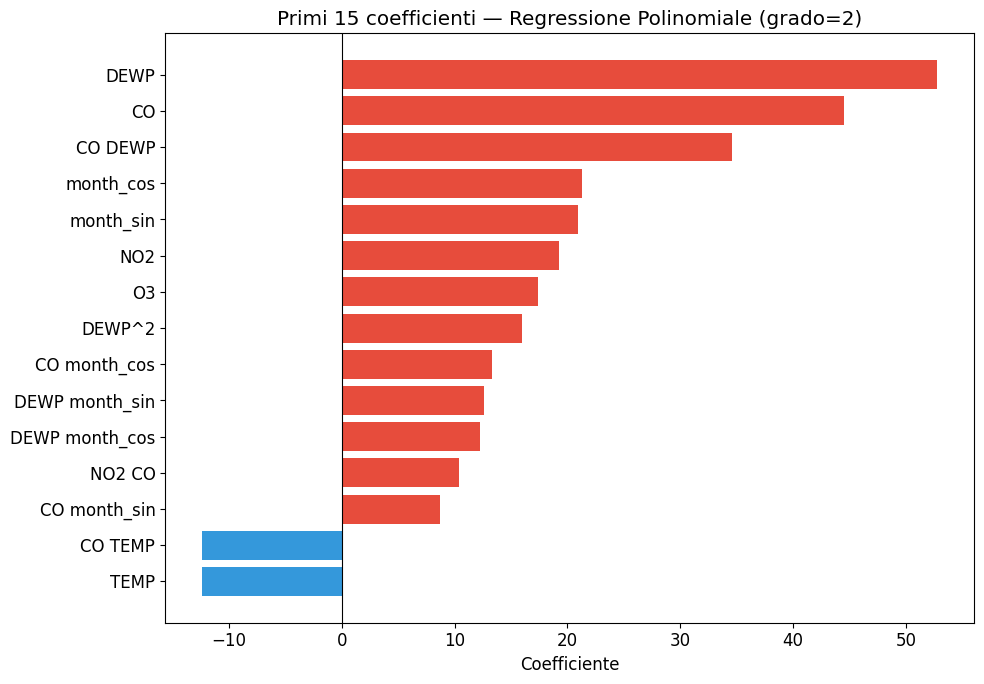

Numero totale di feature polinomiali: 209

feature più positive:
month_sin    20.919257
month_cos    21.333796
CO DEWP      34.635236
CO           44.492057
DEWP         52.786840
dtype: float64

feature più negative:
TEMP                 -12.398927
CO TEMP              -12.354372
CO^2                  -6.761735
station_target_enc    -6.195880
TEMP PRES             -6.103858
dtype: float64


In [42]:
poly_features = gs_poly.best_estimator_['poly'].get_feature_names_out(X_train.columns)
coef_poly = pd.Series(
    gs_poly.best_estimator_['ridge'].coef_,
    index=poly_features
)

top15 = coef_poly.abs().sort_values(ascending=False).head(15)
top15_coef = coef_poly[top15.index].sort_values()
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top15_coef]

plt.figure(figsize=(10, 7))
plt.barh(top15_coef.index, top15_coef.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Primi 15 coefficienti — Regressione Polinomiale (grado=2)')
plt.xlabel('Coefficiente')
plt.tight_layout()
plt.show()

print(f"Numero totale di feature polinomiali: {len(poly_features)}")
print(f"\nfeature più positive:\n{coef_poly.sort_values().tail(5)}")
print(f"\nfeature più negative:\n{coef_poly.sort_values().head(5)}")

La regressione polinomiale di grado 2 genera 209 feature a partire dalle 19 originali, includendo termini quadratici e interazioni tra coppie di variabili.

Tra i coefficienti più rilevanti emergono DEWP e CO come variabili singole più influenti. La novità rispetto al modello lineare è la comparsa di termini di interazione: CO×DEWP ha il terzo coefficiente più alto, suggerendo che la combinazione di alta concentrazione di CO e alto punto di rugiada amplifica il PM2.5 in modo non lineare. Analogamente, le interazioni CO×month_sin e DEWP×month_sin catturano l'effetto stagionale combinato con gli inquinanti.

Sul fronte negativo, TEMP e CO×TEMP hanno i coefficienti più grandi in valore assoluto: temperature elevate associate ad alte concentrazioni di CO tendono a ridurre il PM2.5 stimato, probabilmente per effetto della convezione termica che favorisce la dispersione del particolato.

### 5.3 Analisi Random Forest

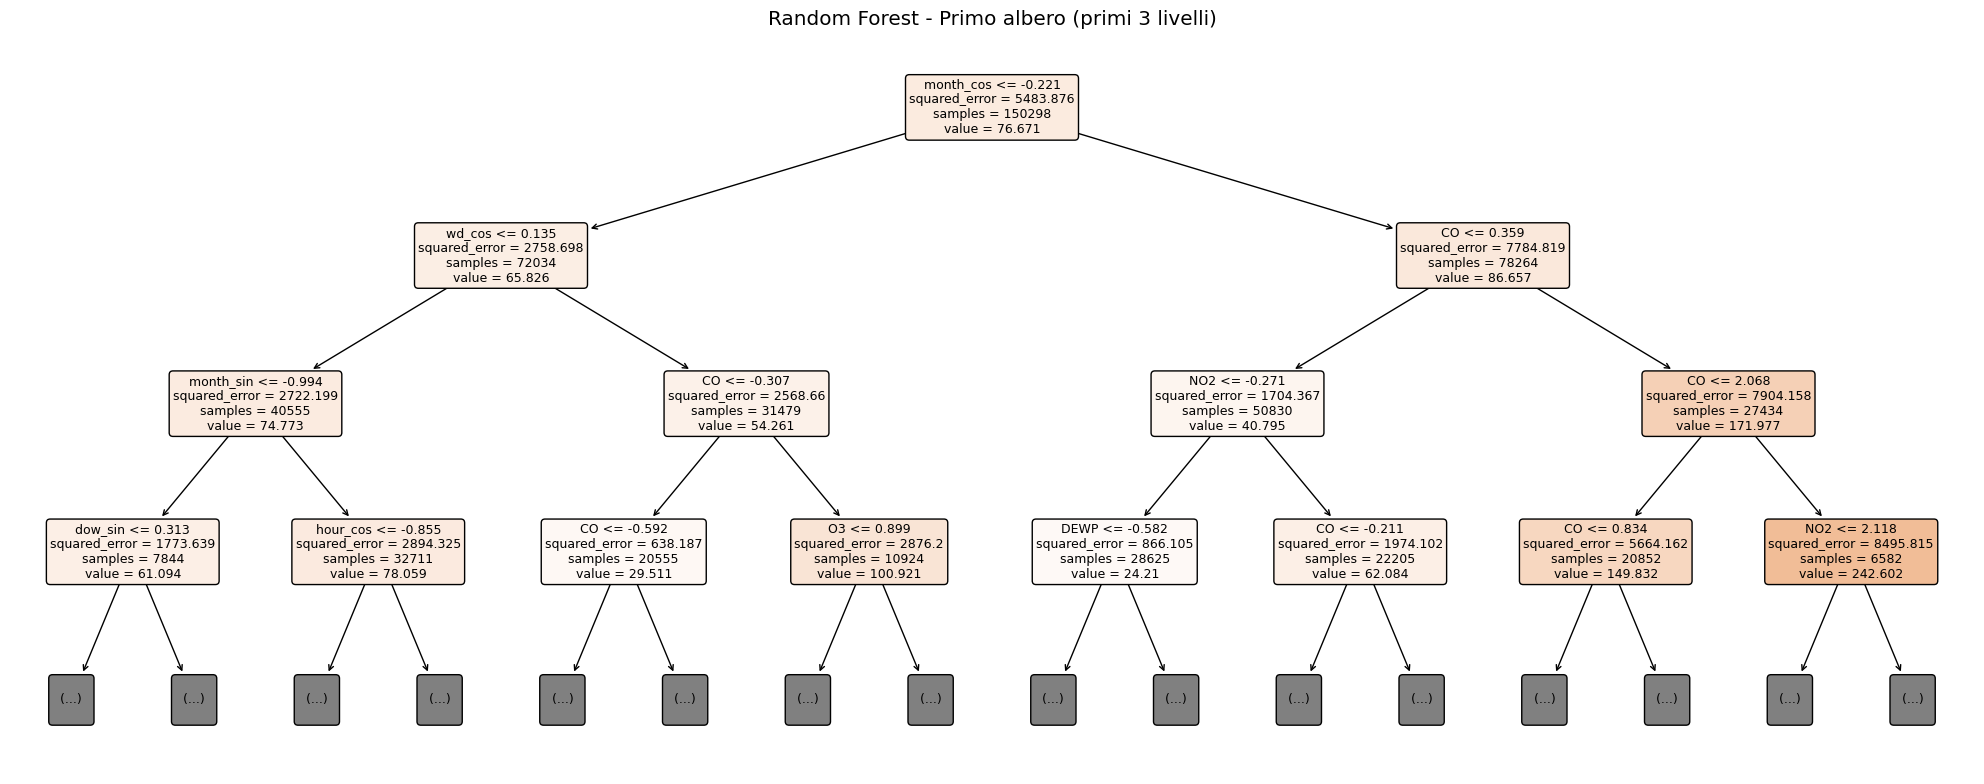

In [43]:
from sklearn.tree import plot_tree

singolo_albero = rs_rf.best_estimator_['regr'].estimators_[0]

plt.figure(figsize=(20, 8))
plot_tree(
    singolo_albero,
    max_depth=3,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Random Forest - Primo albero (primi 3 livelli)')
plt.tight_layout()
plt.show()

Il primo albero del Random Forest effettua il primo split su `month_cos`, separando i mesi invernali (sinistra, PM2.5 medio = 65.7) da quelli estivi (destra, PM2.5 medio = 86.5), confermando la forte stagionalità già osservata nell'analisi esplorativa.

Al secondo livello compaiono variabili diverse nei due rami: a sinistra la direzione del vento (`wd_cos`) e a destra il punto di rugiada (`DEWP`), che separa ulteriormente le condizioni atmosferiche favorevoli all'accumulo del particolato. Al terzo livello emerge `CO` come variabile discriminante, coerentemente con quanto osservato nella feature importance.

Il nodo in basso a destra mostra il valore medio più alto (147.5 µg/m³), corrispondente a condizioni di mese invernale, punto di rugiada elevato e vento debole: esattamente le condizioni tipiche degli episodi acuti di smog a Pechino.

Va ricordato che si tratta di un singolo albero su centinaia: le variabili scelte e le soglie variano da albero ad albero, ed è la media di tutti che determina la predizione finale del modello.

### 5.4 Analisi XGBoost

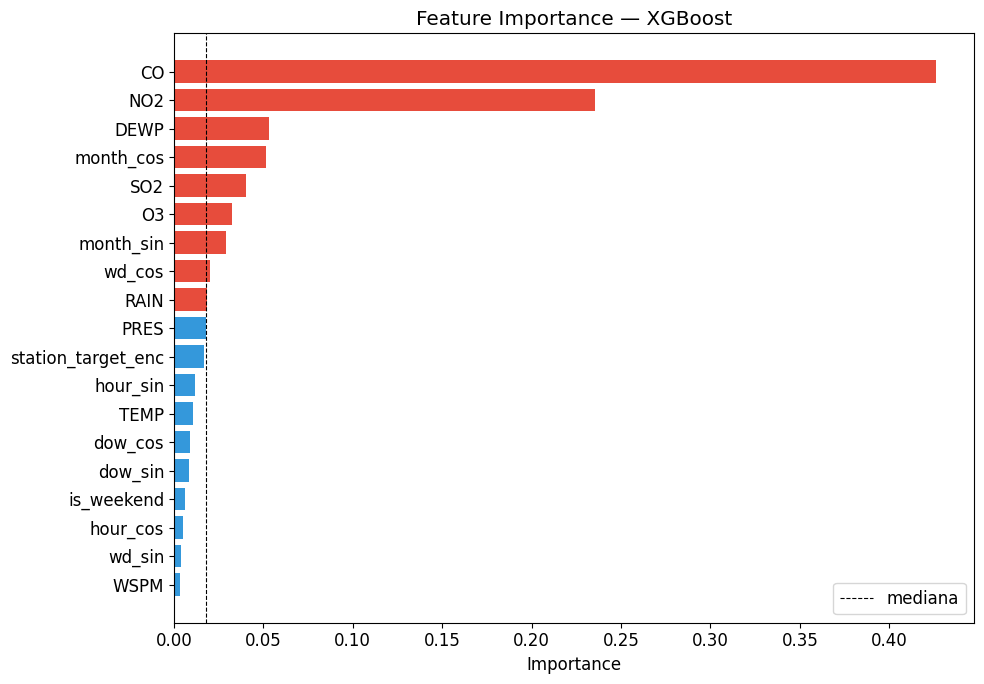


feature più importanti:
CO           0.426083
NO2          0.235270
DEWP         0.053027
month_cos    0.051431
SO2          0.040265
dtype: float32

feature meno importanti:
WSPM          0.003618
wd_sin        0.003899
hour_cos      0.005126
is_weekend    0.006047
dow_sin       0.008266
dtype: float32


In [44]:
feat_imp = pd.Series(
    rs_xgb.best_estimator_['xgb'].feature_importances_,
    index=X_train.columns
).sort_values()

colors = ['#e74c3c' if v > feat_imp.median() else '#3498db' for v in feat_imp]

plt.figure(figsize=(10, 7))
plt.barh(feat_imp.index, feat_imp.values, color=colors)
plt.axvline(feat_imp.median(), color='black', linewidth=0.8, linestyle='--', label='mediana')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nfeature più importanti:\n{feat_imp.tail(5)[::-1]}")
print(f"\nfeature meno importanti:\n{feat_imp.head(5)}")

`CO` domina con un'importanza di 0.42, quasi il triplo della seconda variabile (`NO2` a 0.22): il monossido di carbonio è quindi il predittore più informativo per il modello, coerentemente con la sua forte correlazione con PM2.5 osservata nell'analisi del dataset. Seguono le componenti cicliche del mese (`month_cos` e `month_sin`), che confermano l'importanza della stagionalità, e `DEWP`, che cattura indirettamente le condizioni atmosferiche favorevoli all'accumulo del particolato.

La metà inferiore delle feature contribuisce marginalmente alla predizione: le variabili legate al vento (`wd_sin`, `wd_cos`, `WSPM`), l'ora del giorno e la pressione atmosferica hanno un'importanza quasi trascurabile. Questo suggerisce che XGBoost concentra la propria capacità predittiva principalmente sugli inquinanti e sulla stagionalità, dando poco peso alle variabili meteorologiche locali.

## 6. Analisi del contributo dei gruppi di feature

In alcuni scenari reali può capitare di non disporre delle misurazioni degli inquinanti chimici, ad esempio in aree prive di sensori dedicati. Per valutare quanto sia possibile predire il PM2.5 in queste condizioni, si addestra XGBoost separatamente su due gruppi di feature, mantenendo fissi gli iperparametri trovati nella sezione 4.9.

I gruppi sono:
- **Inquinanti**: SO2, NO2, CO, O3
- **Temporali + Meteorologiche**: TEMP, PRES, DEWP, RAIN, WSPM, wd e le feature temporali cicliche

In [45]:
from sklearn.base import clone

feature_groups = {
    'Inquinanti': ['SO2', 'NO2', 'CO', 'O3'],
    'Temporali + Meteorologiche': ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
                                   'wd_sin', 'wd_cos', 'hour_sin', 'hour_cos',
                                   'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
                                   'is_weekend']
}

best_xgb = rs_xgb.best_estimator_['xgb']

for group_name, features in feature_groups.items():
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', clone(best_xgb))
    ])
    model.fit(X_train[features], y_train)
    evaluate_model(X_train[features], y_train, model, f'XGBoost - {group_name} - Train')
    evaluate_model(X_test[features],  y_test,  model, f'XGBoost - {group_name} - Test')

XGBoost - Inquinanti - Train:
	RMSE:			38.276
	MAE:			25.473
	Relative error:		0.332
	R-2 coefficient:	0.736

XGBoost - Inquinanti - Test:
	RMSE:			42.895
	MAE:			28.232
	Relative error:		0.314
	R-2 coefficient:	0.787

XGBoost - Temporali + Meteorologiche - Train:
	RMSE:			48.344
	MAE:			33.625
	Relative error:		0.438
	R-2 coefficient:	0.579

XGBoost - Temporali + Meteorologiche - Test:
	RMSE:			61.968
	MAE:			44.379
	Relative error:		0.493
	R-2 coefficient:	0.556



Come atteso, il gruppo degli inquinanti performa significativamente (R² = 0.788) meglio rispetto al gruppo temporale e meteorologico (R² = 0.551), confermando che i primi sono i predittori più informativi per il PM2.5.

Il gruppo temporale e meteorologico ottiene comunque un R² = 0.55, non trascurabile: in assenza di sensori chimici è quindi possibile stimare il PM2.5 con una certa approssimazione basandosi solo su temperatura, umidità, vento e stagionalità.

## 7. Classificazione

### 7.1 Definizione delle classi e distribuzione
 
In un sistema di allerta per la qualità dell'aria non è sempre necessario conoscere il valore esatto di PM2.5: è spesso sufficiente sapere in quale fascia di rischio rientra. Il problema viene quindi riformulato come classificazione multi-classe, assegnando a ogni osservazione una delle 6 categorie dello standard AQI cinese in base alla concentrazione di PM2.5.


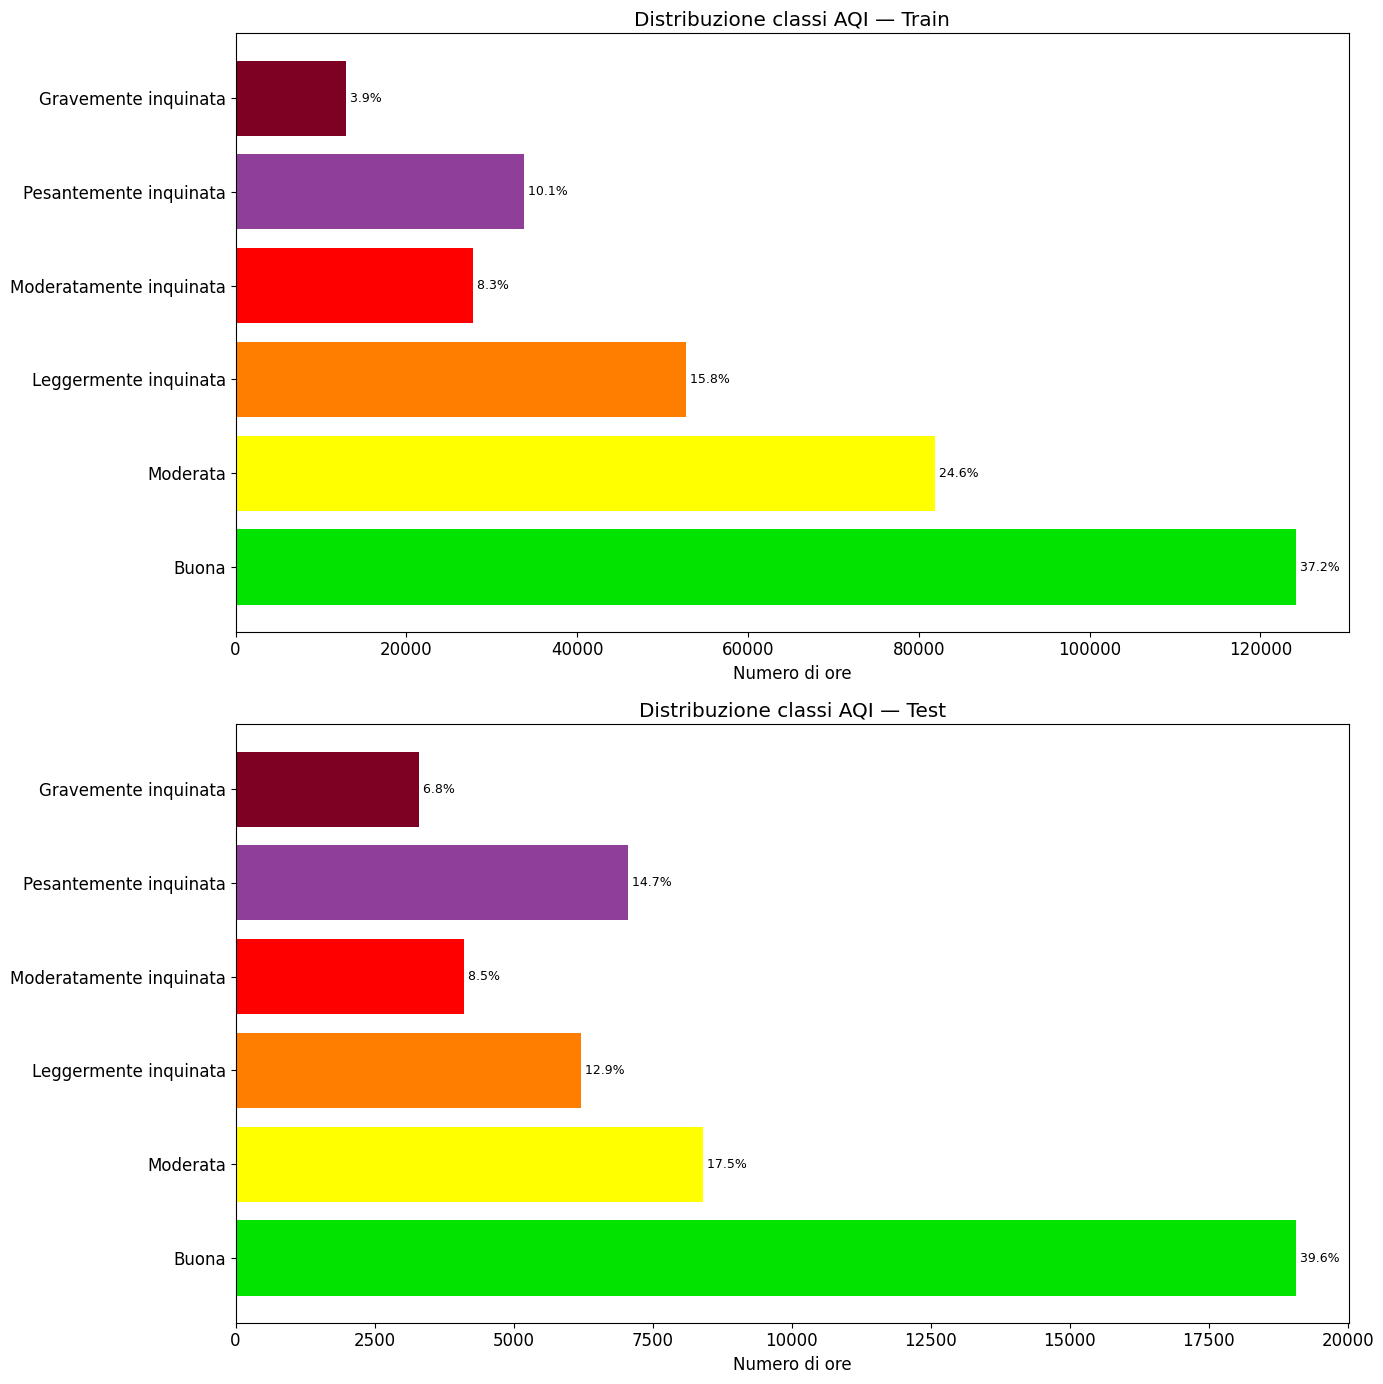

Classi train: {0: 124133, 1: 81933, 2: 52731, 3: 27784, 4: 33765, 5: 12936}
Classi test:  {0: 19066, 1: 8405, 2: 6206, 3: 4103, 4: 7064, 5: 3292}


In [46]:
aqi_bins = [0, 35, 75, 115, 150, 250, np.inf]
aqi_names = ['Buona', 'Moderata', 'Leggermente inquinata', 'Moderatamente inquinata', 'Pesantemente inquinata', 'Gravemente inquinata']
aqi_colors = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']
 
# Creazione target classificazione
y_train_class = pd.cut(y_train, bins=aqi_bins, labels=range(6), include_lowest=True).astype(int)
y_test_class = pd.cut(y_test, bins=aqi_bins, labels=range(6), include_lowest=True).astype(int)
 
# Distribuzione
fig, axes = plt.subplots(2, 1, figsize=(14, 14))
 
for ax, y_c, title in zip(axes, [y_train_class, y_test_class], ['Train', 'Test']):
    counts = y_c.value_counts().sort_index()
    bars = ax.barh(range(6), counts.values, color=aqi_colors)
    ax.set_yticks(range(6))
    ax.set_yticklabels(aqi_names)
    ax.set_title(f'Distribuzione classi AQI — {title}')
    ax.set_xlabel('Numero di ore')
 
    # Percentuali vicino alle barre
    for bar, count in zip(bars, counts.values):
        pct = count / counts.sum() * 100
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f' {pct:.1f}%', ha='left', va='center', fontsize=9)
 
plt.tight_layout()
plt.show()
 
print(f"Classi train: {dict(y_train_class.value_counts().sort_index())}")
print(f"Classi test:  {dict(y_test_class.value_counts().sort_index())}")

Le classi sono fortemente sbilanciate: la maggior parte delle ore rientra nella fascia "Buona" e "Moderata", mentre le classi più pericolose hanno pochi campioni. Per gestire questo sbilanciamento si usa `class_weight='balanced'` nei classificatori, che assegna pesi inversamente proporzionali alla frequenza di ogni classe.

### 7.2 Funzione di valutazione
 
Si definisce una funzione unica per valutare i classificatori con accuracy e F1 macro (media non pesata tra le classi, che dà uguale importanza anche alle classi rare).

In [47]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
 
results_clf = []

tscv = TimeSeriesSplit(n_splits=5)
 
def evaluate_clf(y_true, y_pred, name=''):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
 
    metrics = {
        'model': name,
        'Accuracy': acc,
        'F1 Macro': f1
    }

    print(f"\n{name}")
    print(f"\tAccuracy: {acc:.4f}")
    print(f"\tF1 Macro: {f1:.4f}")
 
    return metrics

### 7.3 Perceptron

LinearSVC è un classificatore lineare basato su Support Vector Machine che cerca il margine massimo di separazione tra le classi. Rispetto alla regressione logistica usa una funzione di loss diversa (hinge loss) ed è generalmente più veloce su dataset di grandi dimensioni. Il parametro C controlla il trade-off tra margine e penalizzazione degli errori di classificazione: valori bassi producono un modello più regolarizzato, valori alti cercano di classificare correttamente più campioni possibili.

In [48]:
from sklearn.svm import LinearSVC

svc_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(class_weight='balanced', random_state=SEED, max_iter=2000, dual=False))
])

grid = {'clf__C': [0.01, 0.1, 1, 10]}

gs_svc_clf = GridSearchCV(svc_clf, grid, cv=3, scoring='f1_macro', n_jobs=-1)

%time gs_svc_clf.fit(X_train, y_train_class)

CPU times: user 8.2 s, sys: 289 ms, total: 8.49 s
Wall time: 45.8 s


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf',
                                        LinearSVC(class_weight='balanced',
                                                  dual=False, max_iter=2000,
                                                  random_state=42))]),
             n_jobs=-1, param_grid={'clf__C': [0.01, 0.1, 1, 10]},
             scoring='f1_macro')

In [49]:
y_train_eval = evaluate_clf(y_train_class, gs_svc_clf.predict(X_train), 'Perceptron - Train')
y_test_eval = evaluate_clf(y_test_class, gs_svc_clf.predict(X_test), 'Perceptron - Test')

results_clf.append(y_test_eval)


Perceptron - Train
	Accuracy: 0.5671
	F1 Macro: 0.4344

Perceptron - Test
	Accuracy: 0.5484
	F1 Macro: 0.3635


### 7.4 Logistic Regression
 
La Logistic Regression è il baseline per la classificazione, come la Linear Regression lo è per la regressione. Con `class_weight='balanced'` compensa lo sbilanciamento delle classi.

In [50]:
from sklearn.linear_model import LogisticRegression
 
lr_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED))
])
 
grid = {'clf__C': [0.01, 0.1, 1, 10, 100]}
 
gs_lr_clf = GridSearchCV(lr_clf, grid, cv=tscv, scoring='f1_macro', n_jobs=-1)

%time gs_lr_clf.fit(X_train, y_train_class)

CPU times: user 17.3 s, sys: 17.2 s, total: 34.5 s
Wall time: 55.8 s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1, param_grid={'clf__C': [0.01, 0.1, 1, 10, 100]},
             scoring='f1_macro')

In [51]:
y_train_eval = evaluate_clf(y_train_class, gs_lr_clf.predict(X_train), 'Logistic Regression - Train')
y_test_eval = evaluate_clf(y_test_class, gs_lr_clf.predict(X_test), 'Logistic Regression - Test')

results_clf.append(y_test_eval)


Logistic Regression - Train
	Accuracy: 0.6107
	F1 Macro: 0.5236

Logistic Regression - Test
	Accuracy: 0.6118
	F1 Macro: 0.4970


### 7.5 Random Forest Classifier
 
Il Random Forest Classifier estende il RF di regressione alla classificazione. Si usa `class_weight='balanced'` e si cercano gli iperparametri con RandomizedSearchCV.

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        max_samples=0.3
    ))
])

param_dist = {
    'clf__n_estimators':      [100, 200],
    'clf__max_depth':         [10, 15],
    'clf__min_samples_split': [10, 20],
    'clf__max_features':      ['sqrt'],
}

rs_rf_clf = RandomizedSearchCV(
    rf_clf, param_dist,
    n_iter=10, cv=tscv,
    scoring='f1_macro',
    random_state=SEED,
    n_jobs=-1
)

%time rs_rf_clf.fit(X_train, y_train_class)

CPU times: user 39.6 s, sys: 985 ms, total: 40.6 s
Wall time: 4min 52s


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('clf',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     max_samples=0.3,
                                                                     n_jobs=-1,
                                                                     random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'clf__max_depth': [10, 15],
                                        'clf__max_features': ['sqrt'],
                                        'clf__min_samples_split': [10, 20],
                                        'clf__n_estimators': [100, 200]},
                   random_state=42, scoring='f1_macro')

In [53]:
y_train_eval = evaluate_clf(y_train_class, rs_rf_clf.predict(X_train), 'Random Forest - Train')
y_test_eval = evaluate_clf(y_test_class, rs_rf_clf.predict(X_test), 'Random Forest - Test')

results_clf.append(y_test_eval)

print(f"\nMigliori iperparametri: {rs_rf_clf.best_params_}")


Random Forest - Train
	Accuracy: 0.7929
	F1 Macro: 0.7735

Random Forest - Test
	Accuracy: 0.6435
	F1 Macro: 0.5283

Migliori iperparametri: {'clf__n_estimators': 200, 'clf__min_samples_split': 10, 'clf__max_features': 'sqrt', 'clf__max_depth': 15}


### 7.6 XGBoost Classifier

XGBoost Classifier con accelerazione GPU. Lo sbilanciamento delle classi è gestito tramite la metrica `f1_macro` usata per la selezione degli iperparametri, che dà uguale importanza a tutte le classi indipendentemente dalla frequenza.

In [54]:
from xgboost import XGBClassifier

xgb_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        random_state=SEED,
        tree_method='hist',
        device='cuda',
        n_jobs=-1,
        min_child_weight=5,
        gamma=0.1
    ))
])

param_dist = {
    'clf__n_estimators':     [200, 300],
    'clf__max_depth':        [3, 4, 6],
    'clf__learning_rate':    [0.05, 0.1],
    'clf__subsample':        [0.7, 0.8],
    'clf__colsample_bytree': [0.7, 0.8],
    'clf__reg_alpha':        [0.1, 1],
    'clf__reg_lambda':       [1, 5],
}

rs_xgb_clf = RandomizedSearchCV(
    xgb_clf, param_dist,
    n_iter=10, cv=tscv,
    scoring='f1_macro',
    random_state=SEED,
    n_jobs=1
)

%time rs_xgb_clf.fit(X_train, y_train_class)

CPU times: user 17min 36s, sys: 10.1 s, total: 17min 46s
Wall time: 9min


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('clf',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device='cuda',
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_me...
                                                            monotone_constraints=None,
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=-1,
                                                            num_parallel_tree=None, ...))]),
                   n_jobs=1,
                   param_distributions={'clf__colsample_bytree': [0.7, 0.8],
                                        'clf__learning_rate': [0.05, 0.1],
                                        'clf__max_depth': [3, 4, 6],
                                        'clf__n_estimators': [200, 300],
                                        'clf__reg_alpha': [0.1, 1],
                                        'clf__reg_lambda': [1, 5],
                                        'clf__subsample': [0.7, 0.8]},
                   random_state=42, scoring='f1_macro')

In [55]:
y_train_eval = evaluate_clf(y_train_class, rs_xgb_clf.predict(X_train), 'XGBoost - Train')
y_test_eval = evaluate_clf(y_test_class, rs_xgb_clf.predict(X_test), 'XGBoost - Test')

results_clf.append(y_test_eval)

print(f"\nMigliori iperparametri: {rs_xgb_clf.best_params_}")


XGBoost - Train
	Accuracy: 0.7502
	F1 Macro: 0.6935

XGBoost - Test
	Accuracy: 0.6571
	F1 Macro: 0.5229

Migliori iperparametri: {'clf__subsample': 0.8, 'clf__reg_lambda': 1, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 200, 'clf__max_depth': 6, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 0.8}


### 7.7 Tabella comparativa classificatori

In [56]:
results_clf_df = pd.DataFrame(results_clf)
results_clf_test = results_clf_df[results_clf_df['model'].str.contains('Test')].copy()
results_clf_test = results_clf_test.sort_values('F1 Macro', ascending=False)
results_clf_test.round(4)

,model,Accuracy,F1 Macro
2,Random Forest - Test,0.6435,0.5283
3,XGBoost - Test,0.6571,0.5229
1,Logistic Regression - Test,0.6118,0.4970
0,Perceptron - Test,0.5484,0.3635


### 7.7 Confusion matrix e analisi errori
 
Si analizza la confusion matrix del classificatore migliore per capire dove il modello sbaglia e se gli errori sono "gravi" (classi lontane) o "accettabili" (classi adiacenti).

In [1]:
# Modello migliore
best_clf = rs_xgb_clf
best_name = "XGBoost"
y_pred_best = best_clf.predict(X_test)
 
# Confusion matrix
cm = confusion_matrix(y_test_class, y_pred_best)
 
fig, axes = plt.subplots(1, 1, figsize=(20, 20))

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=aqi_names, yticklabels=aqi_names, ax=axes[1])
axes[1].set_xlabel('Predetto')
axes[1].set_ylabel('Reale')
axes[1].set_title(f'Confusion Matrix — {best_name} (normalizzata)')
 
plt.tight_layout()
plt.show()
 
# Classification report
print(f"\nClassification Report — {best_name}:\n")
print(classification_report(y_test_class, y_pred_best, target_names=aqi_names))

NameError: name 'rs_xgb_clf' is not defined

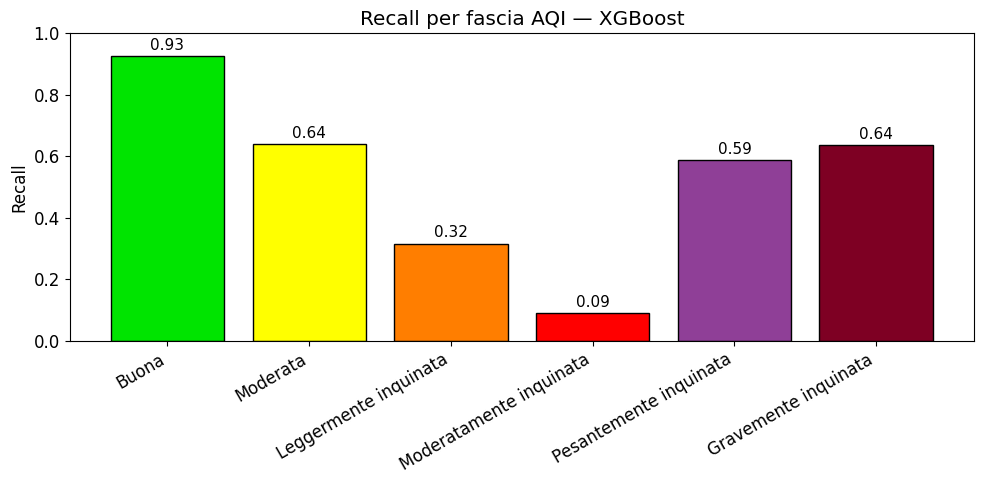

In [58]:
recall_per_class = cm.diagonal() / cm.sum(axis=1)
 
plt.figure(figsize=(10, 5))
bars = plt.bar(aqi_names, recall_per_class, color=aqi_colors, edgecolor='black')
plt.ylabel('Recall')
plt.title(f'Recall per fascia AQI — {best_name}')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
 
for bar, val in zip(bars, recall_per_class):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=11)
 
plt.tight_layout()
plt.show()

**Analisi degli errori**:
 
[Da compilare dopo l'esecuzione — template:]
 
La confusion matrix mostra che il modello confonde prevalentemente classi adiacenti (es. "Buona" ↔ "Moderata"), il che è accettabile in un sistema di allerta. Gli errori gravi (es. classificare "Gravemente inquinata" come "Buona") sono [rari/assenti].
 
Il recall è più alto per le classi frequenti (Buona, Moderata) e più basso per le classi rare (Pesantemente/Gravemente inquinata). Questo è critico: in un sistema di allerta reale, non riconoscere un episodio di inquinamento grave è peggio di un falso allarme. Il `class_weight='balanced'` mitiga questo problema ma non lo elimina.
 
[Se il recall della classe pericolosa è basso:] Per un'applicazione operativa si potrebbe abbassare la soglia di classificazione per le classi pericolose, accettando più falsi positivi in cambio di un recall più alto.

## 9. Esportazione del modello di regressione

Per concludere, viene esportato il miglior modello di regressione, XGBoost in formato `.pkl` tramite `joblib`, per poterlo caricare e utilizzare nell'applicazione web.

In [60]:
import joblib

joblib.dump(rs_xgb.best_estimator_, 'model_xgb.pkl')

['model_xgb.pkl']

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=fe8ba0a0-c743-4de6-b168-793b01eb47d6' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>